# Abbildungen des Ergebnisteils

In [1]:
source("setup.R")
source("cluster_namen.R")

BLAU <- "#2a78d6"; GRUEN <- "#008300"
GRAU <- "#898781"; TINTE <- "#0b0b0b"; TINTE2 <- "#52514e"
RAMPE  <- c("#86b6ef", "#2a78d6", "#104281")              # k = 15 / 50 / 100
RAMPE4 <- c("#a9cbf3", "#5e9ae8", "#2a78d6", "#104281")   # cos 0,55 bis 0,70

# Die zweite Palette gehört zu den FF3-Abbildungen: divergierende Skala mit
# neutraler Mitte, Pole aus ColorBrewer RdBu.
POL_LINKS <- "#2166AC"; POL_RECHTS <- "#B2182B"

theme_ma <- function(base_size = 10) {
  theme_minimal(base_size = base_size) +
    theme(
      text             = element_text(colour = TINTE),
      axis.text        = element_text(colour = TINTE2),
      axis.title       = element_text(colour = TINTE2),
      panel.grid.minor = element_blank(),
      panel.grid.major = element_line(colour = "#e1e0d9", linewidth = 0.3),
      axis.line.x      = element_line(colour = "#c3c2b7", linewidth = 0.4),
      legend.position  = "bottom",
      legend.title     = element_blank(),
      legend.key.width = unit(1.1, "cm"),
      plot.title       = element_text(face = "bold", size = base_size + 1),
      plot.subtitle    = element_text(colour = TINTE2, size = base_size - 0.5),
      plot.caption     = element_text(colour = GRAU, size = base_size - 1.5, hjust = 0),
      plot.background  = element_rect(fill = "white", colour = NA),
      plot.margin      = margin(6, 14, 6, 6))
}

komma <- scales::label_number(accuracy = 0.01, decimal.mark = ",", big.mark = ".")
fmt   <- function(x, d = 3) formatC(x, format = "f", digits = d, decimal.mark = ",")
uz    <- function(s) str_wrap(s, width = 88)   # Untertitel umbrechen statt abschneiden

# Griechische Zeichen: das Standard-pdf()-Device auf Windows rechnet mit
# Helvetica-Metriken ohne diese Glyphen und lässt eta, omega und tau lautlos
# verschwinden, wo sie als echter Text gezeichnet werden. Deshalb durchgehend
# Cairo. Nicht auf die Default-Devices zurücksetzen.
if (!isTRUE(capabilities("cairo")))
  warning("Kein Cairo in dieser R-Installation, griechische Zeichen fehlen dann.")

sichern <- function(p, name, breite = 16, hoehe = 9.5) {
  ggsave(file.path(ABB_DIR, paste0(name, ".pdf")), p, width = breite, height = hoehe,
         units = "cm", bg = "white", device = grDevices::cairo_pdf)
  ggsave(file.path(ABB_DIR, paste0(name, ".png")), p, width = breite, height = hoehe,
         units = "cm", dpi = 300, bg = "white", type = "cairo")
  cat("  ->", name, "(pdf + png)\n")
}

# Direktlabel am rechten Linienende. nudge verschiebt Labels, die am Endpunkt
# übereinanderfallen.
endlabel <- function(d, xvar, yvar, lab, nudge = NULL) {
  e <- d |> group_by(.data[[lab]]) |> slice_max(.data[[xvar]], n = 1) |> ungroup()
  if (!is.null(nudge)) {
    v <- nudge[as.character(e[[lab]])]; v[is.na(v)] <- 0
    e[[yvar]] <- e[[yvar]] + v
  }
  geom_text(data = e, aes(x = .data[[xvar]], y = .data[[yvar]], label = .data[[lab]],
                          colour = .data[[lab]]),
            hjust = -0.12, size = 2.7, show.legend = FALSE)
}

reflabel <- function(d, text) {
  geom_text(data = slice_max(d, jahr), aes(label = text),
            hjust = -0.08, size = 2.7, colour = GRAU)
}

jahre_achse <- scale_x_continuous(breaks = seq(2016, 2024, 2),
                                  expand = expansion(mult = c(0.02, 0.30)))

lies <- function(name) read_csv(file.path(OUT_DIR, name), show_col_types = FALSE)

trends   <- lies("ff2_trends.csv")
trends_k <- lies("ff2_moran_ksweep_lifestyle_trends.csv")
trends_th <- lies("ff2_moran_threshold_lifestyle_trends.csv")

# tau nie hartkodieren, immer aus der Trendtabelle holen
tau_von <- function(m, tab = trends) {
  tab$tau[match(m, tab$mass)]
}

cat("Abbildungen nach:", normalizePath(ABB_DIR), "\n")

data.table 1.17.8 using 8 threads (see ?getDTthreads).  Latest news: r-datatable.com

Attaching package: ‘igraph’

The following objects are masked from ‘package:stats’:

    decompose, spectrum

The following object is masked from ‘package:base’:

    union


Attaching package: ‘dbscan’

The following object is masked from ‘package:stats’:

    as.dendrogram

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.2     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.1.0     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ lubridate::%--%()      masks igraph::%--%()
✖ dplyr::as_data_frame() masks tibble::as_data_frame(), igraph::as_data_frame()
✖ dplyr::between()       masks data.table::between()
✖ purrr::compose()       masks igraph::compose()
✖ tidyr::crossing()      masks igraph::crossing()
✖ dplyr::filte

Warning messages:
1: package ‘igraph’ was built under R version 4.5.3 
2: package ‘ineq’ was built under R version 4.5.2 


## Stichprobe

In [2]:
sc <- read_csv(SCORE_CSV, show_col_types = FALSE) |>
  rename(subreddit = 1) |>
  pivot_longer(starts_with("score_"), names_to = "jahr", values_to = "score",
               names_prefix = "score_", names_transform = list(jahr = as.integer))

s16 <- sc |> filter(jahr == 2016, !is.na(score))
mu  <- mean(s16$score); sdv <- sd(s16$score)
s16 <- s16 |> mutate(z = (score - mu) / sdv, pct = percent_rank(score))

cat(sprintf("2016: n = %d | Mittel = %.4f | SD = %.4f | Schiefe = %.2f\n",
            nrow(s16), mu, sdv, mean((s16$score - mu)^3) / sdv^3))
cat(sprintf("  rechts der Mitte %.1f %% | links %.1f %% | nahe der Mitte (|z| < 0,5) %.1f %%\n",
            100 * mean(s16$z > 0), 100 * mean(s16$z < 0), 100 * mean(abs(s16$z) < 0.5)))
cat(sprintf("  deutlich rechts z > 1: %.1f %% | z > 2: %.1f %%\n",
            100 * mean(s16$z > 1), 100 * mean(s16$z > 2)))
cat(sprintf("  deutlich links  z < -1: %.1f %% | z < -2: %.1f %%\n",
            100 * mean(s16$z < -1), 100 * mean(s16$z < -2)))

anker <- c("Conservative", "The_Donald", "Republican", "politics",
           "SandersForPresident", "hillaryclinton", "democrats")
cat("\nVerankerung der Achse 2016:\n")
print(s16 |> filter(subreddit %in% anker) |>
        transmute(subreddit, score = round(score, 3), z = round(z, 2),
                  perzentil = round(pct, 3)) |> arrange(z), n = 20)

New names:
• `` -> `...1`
2016: n = 16618 | Mittel = 0.0050 | SD = 0.0675 | Schiefe = -0.10
  rechts der Mitte 50.6 % | links 49.4 % | nahe der Mitte (|z| < 0,5) 39.6 %
  deutlich rechts z > 1: 14.8 % | z > 2: 2.1 %
  deutlich links  z < -1: 14.8 % | z < -2: 2.5 %

Verankerung der Achse 2016:
# A tibble: 7 × 4
  subreddit            score     z perzentil
  <chr>                <dbl> <dbl>     <dbl>
1 hillaryclinton      -0.346 -5.2      0    
2 democrats           -0.345 -5.19     0    
3 SandersForPresident -0.266 -4.02     0.001
4 politics            -0.047 -0.77     0.207
5 Republican           0.305  4.44     0.999
6 The_Donald           0.363  5.3      1    
7 Conservative         0.419  6.14     1    


## FF1

  -> ff1_abb1_masse (pdf + png)


Warning message:
Using ragg device as default. Ignoring `type` and `antialias` arguments 


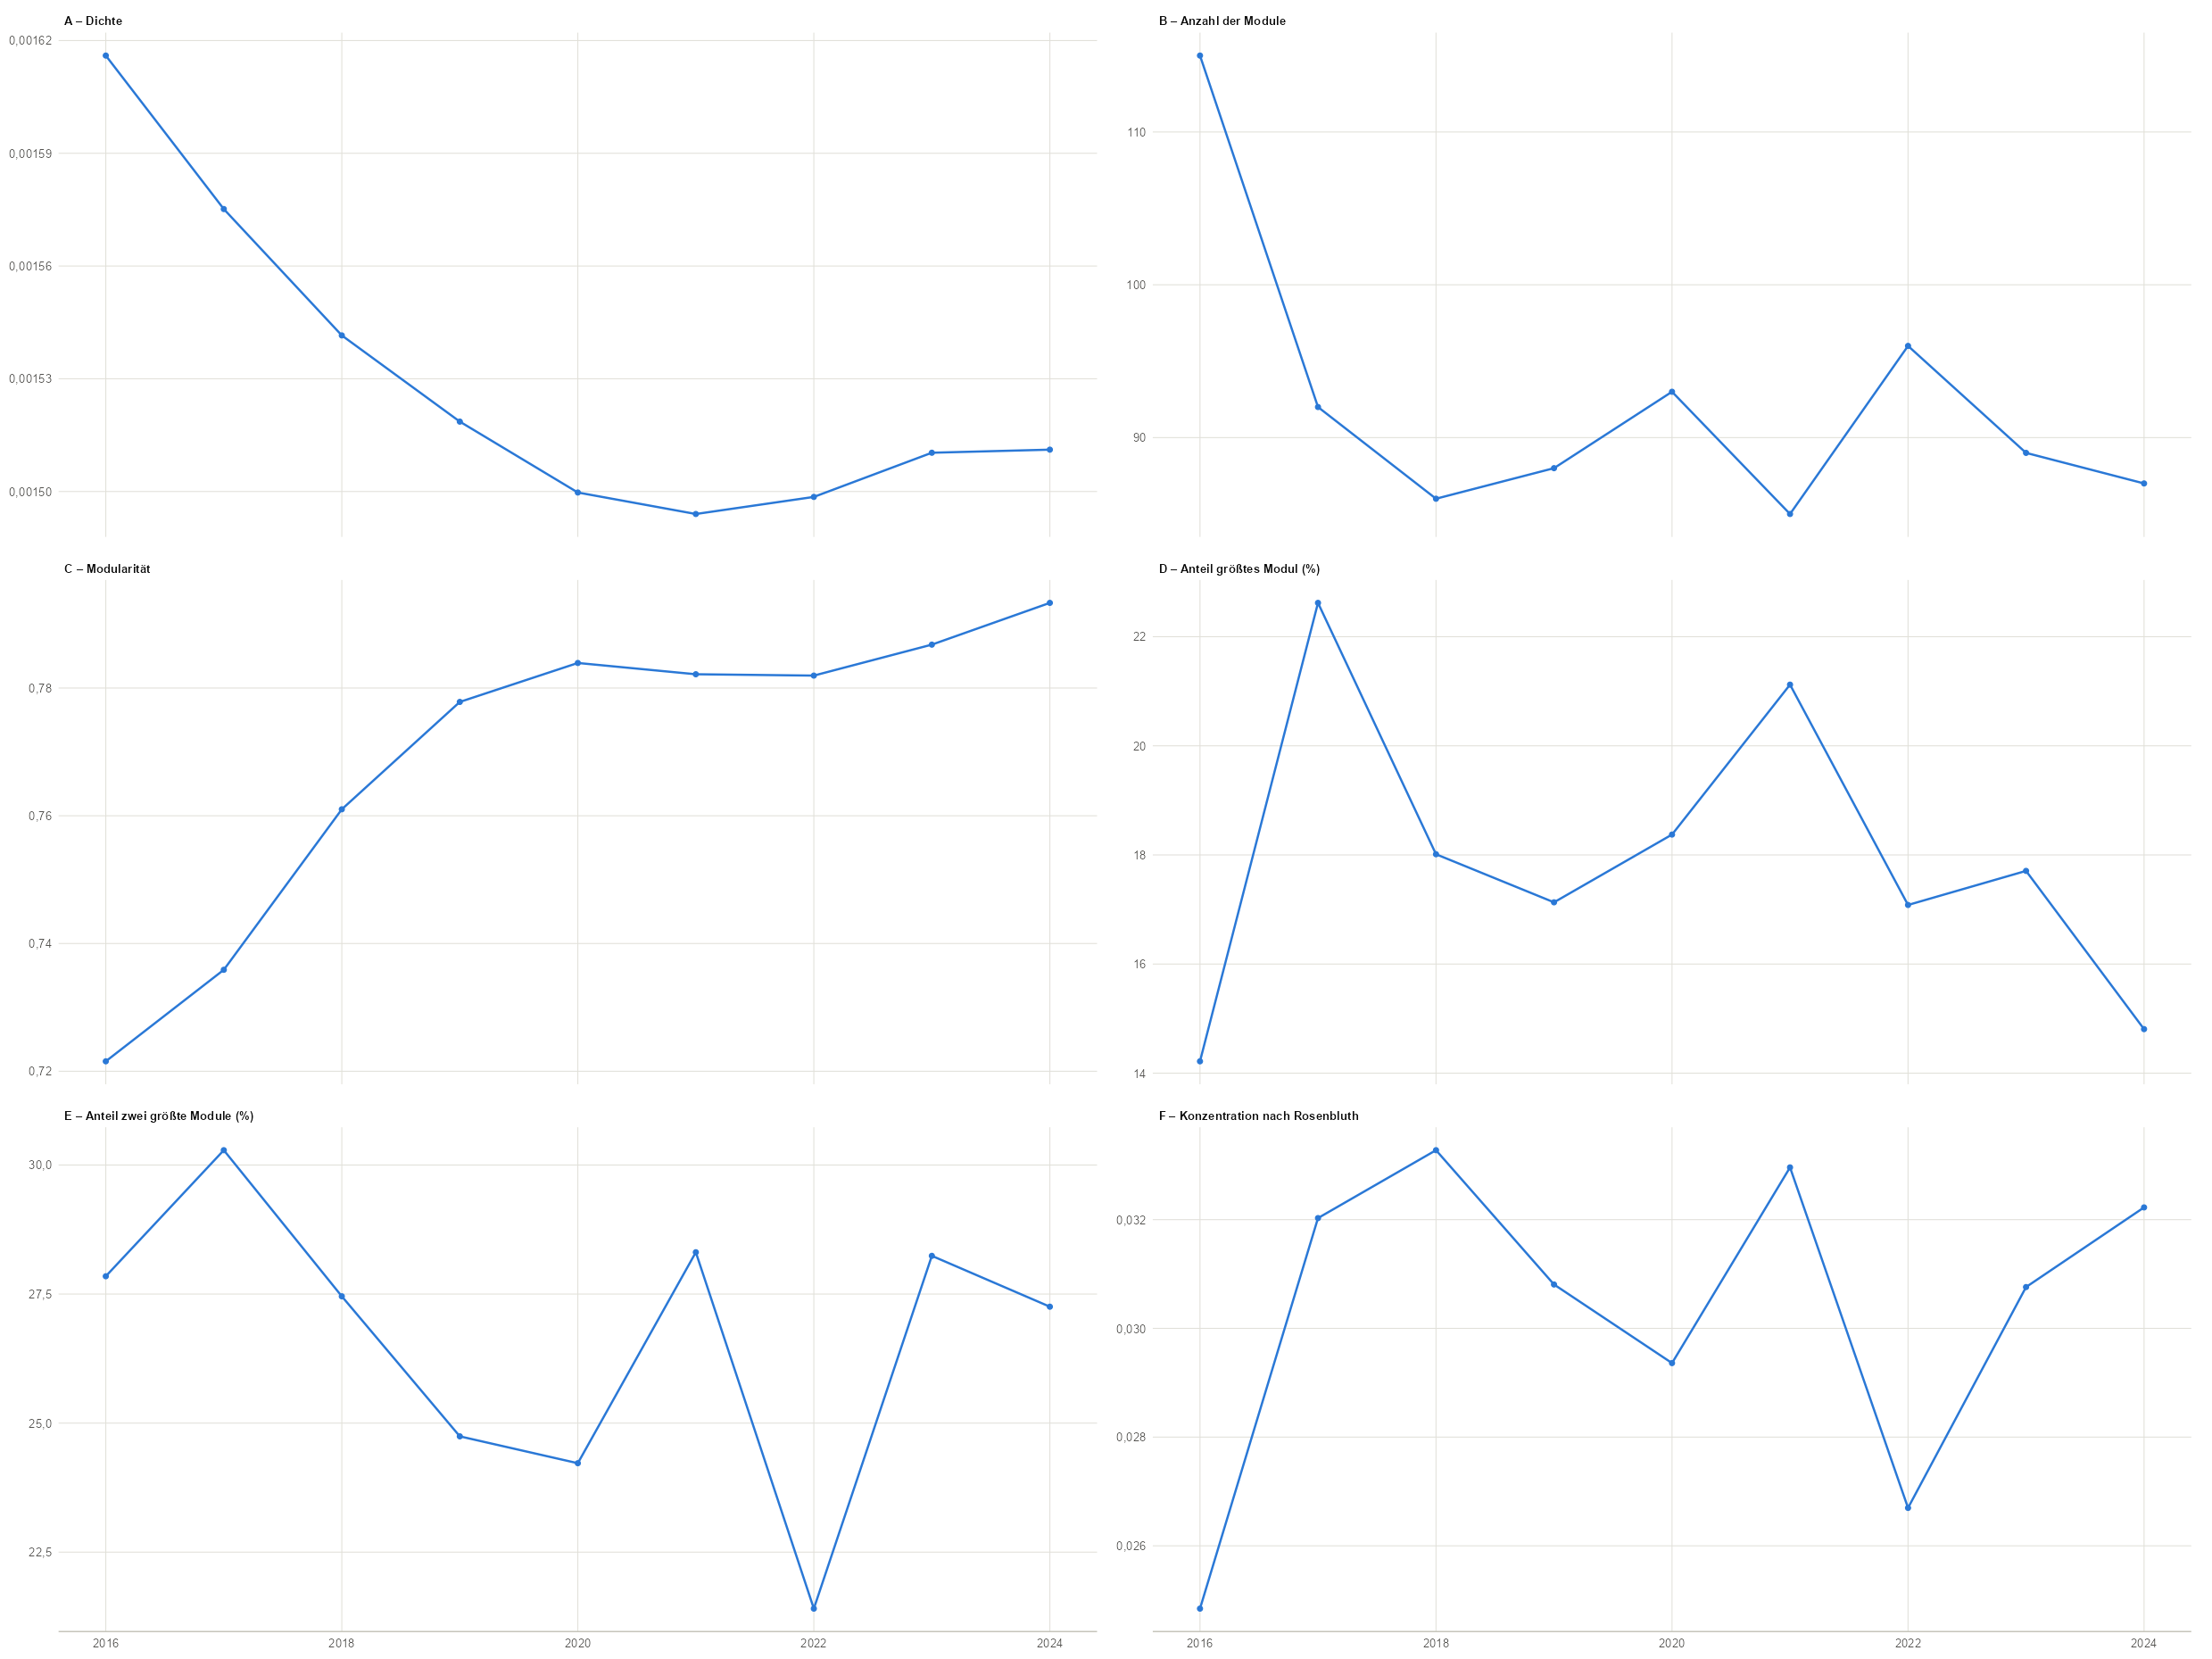

In [3]:
ff1 <- lies("ff1_knn_masse.csv")

panels <- c(density    = "A – Dichte",
            module     = "B – Anzahl der Module",
            Q          = "C – Modularität",
            top1       = "D – Anteil größtes Modul (%)",
            top2       = "E – Anteil zwei größte Module (%)",
            rosenbluth = "F – Konzentration nach Rosenbluth")

lang <- ff1 |>
  mutate(top1 = top1 * 100, top2 = top2 * 100) |>   # DellaPosta zeigt Prozent
  select(jahr, all_of(names(panels))) |>
  pivot_longer(-jahr, names_to = "mass", values_to = "wert") |>
  mutate(panel = factor(panels[mass], levels = unname(panels)))

p_ff1 <- ggplot(lang, aes(jahr, wert)) +
  geom_line(colour = BLAU, linewidth = 0.7) +
  geom_point(colour = BLAU, size = 1.3) +
  facet_wrap(~ panel, ncol = 2, scales = "free_y") +
  scale_x_continuous(breaks = seq(2016, 2024, 2)) +
  scale_y_continuous(labels = scales::label_number(decimal.mark = ",", big.mark = ".")) +
  labs(x = NULL, y = NULL) +
  theme_ma() +
  theme(strip.text = element_text(face = "bold", hjust = 0, colour = TINTE),
        panel.spacing = unit(0.9, "lines"))

sichern(p_ff1, "ff1_abb1_masse", breite = 16, hoehe = 17)
p_ff1

  -> ff1_abb2_kontrast (pdf + png)


Warning message:
Using ragg device as default. Ignoring `type` and `antialias` arguments 


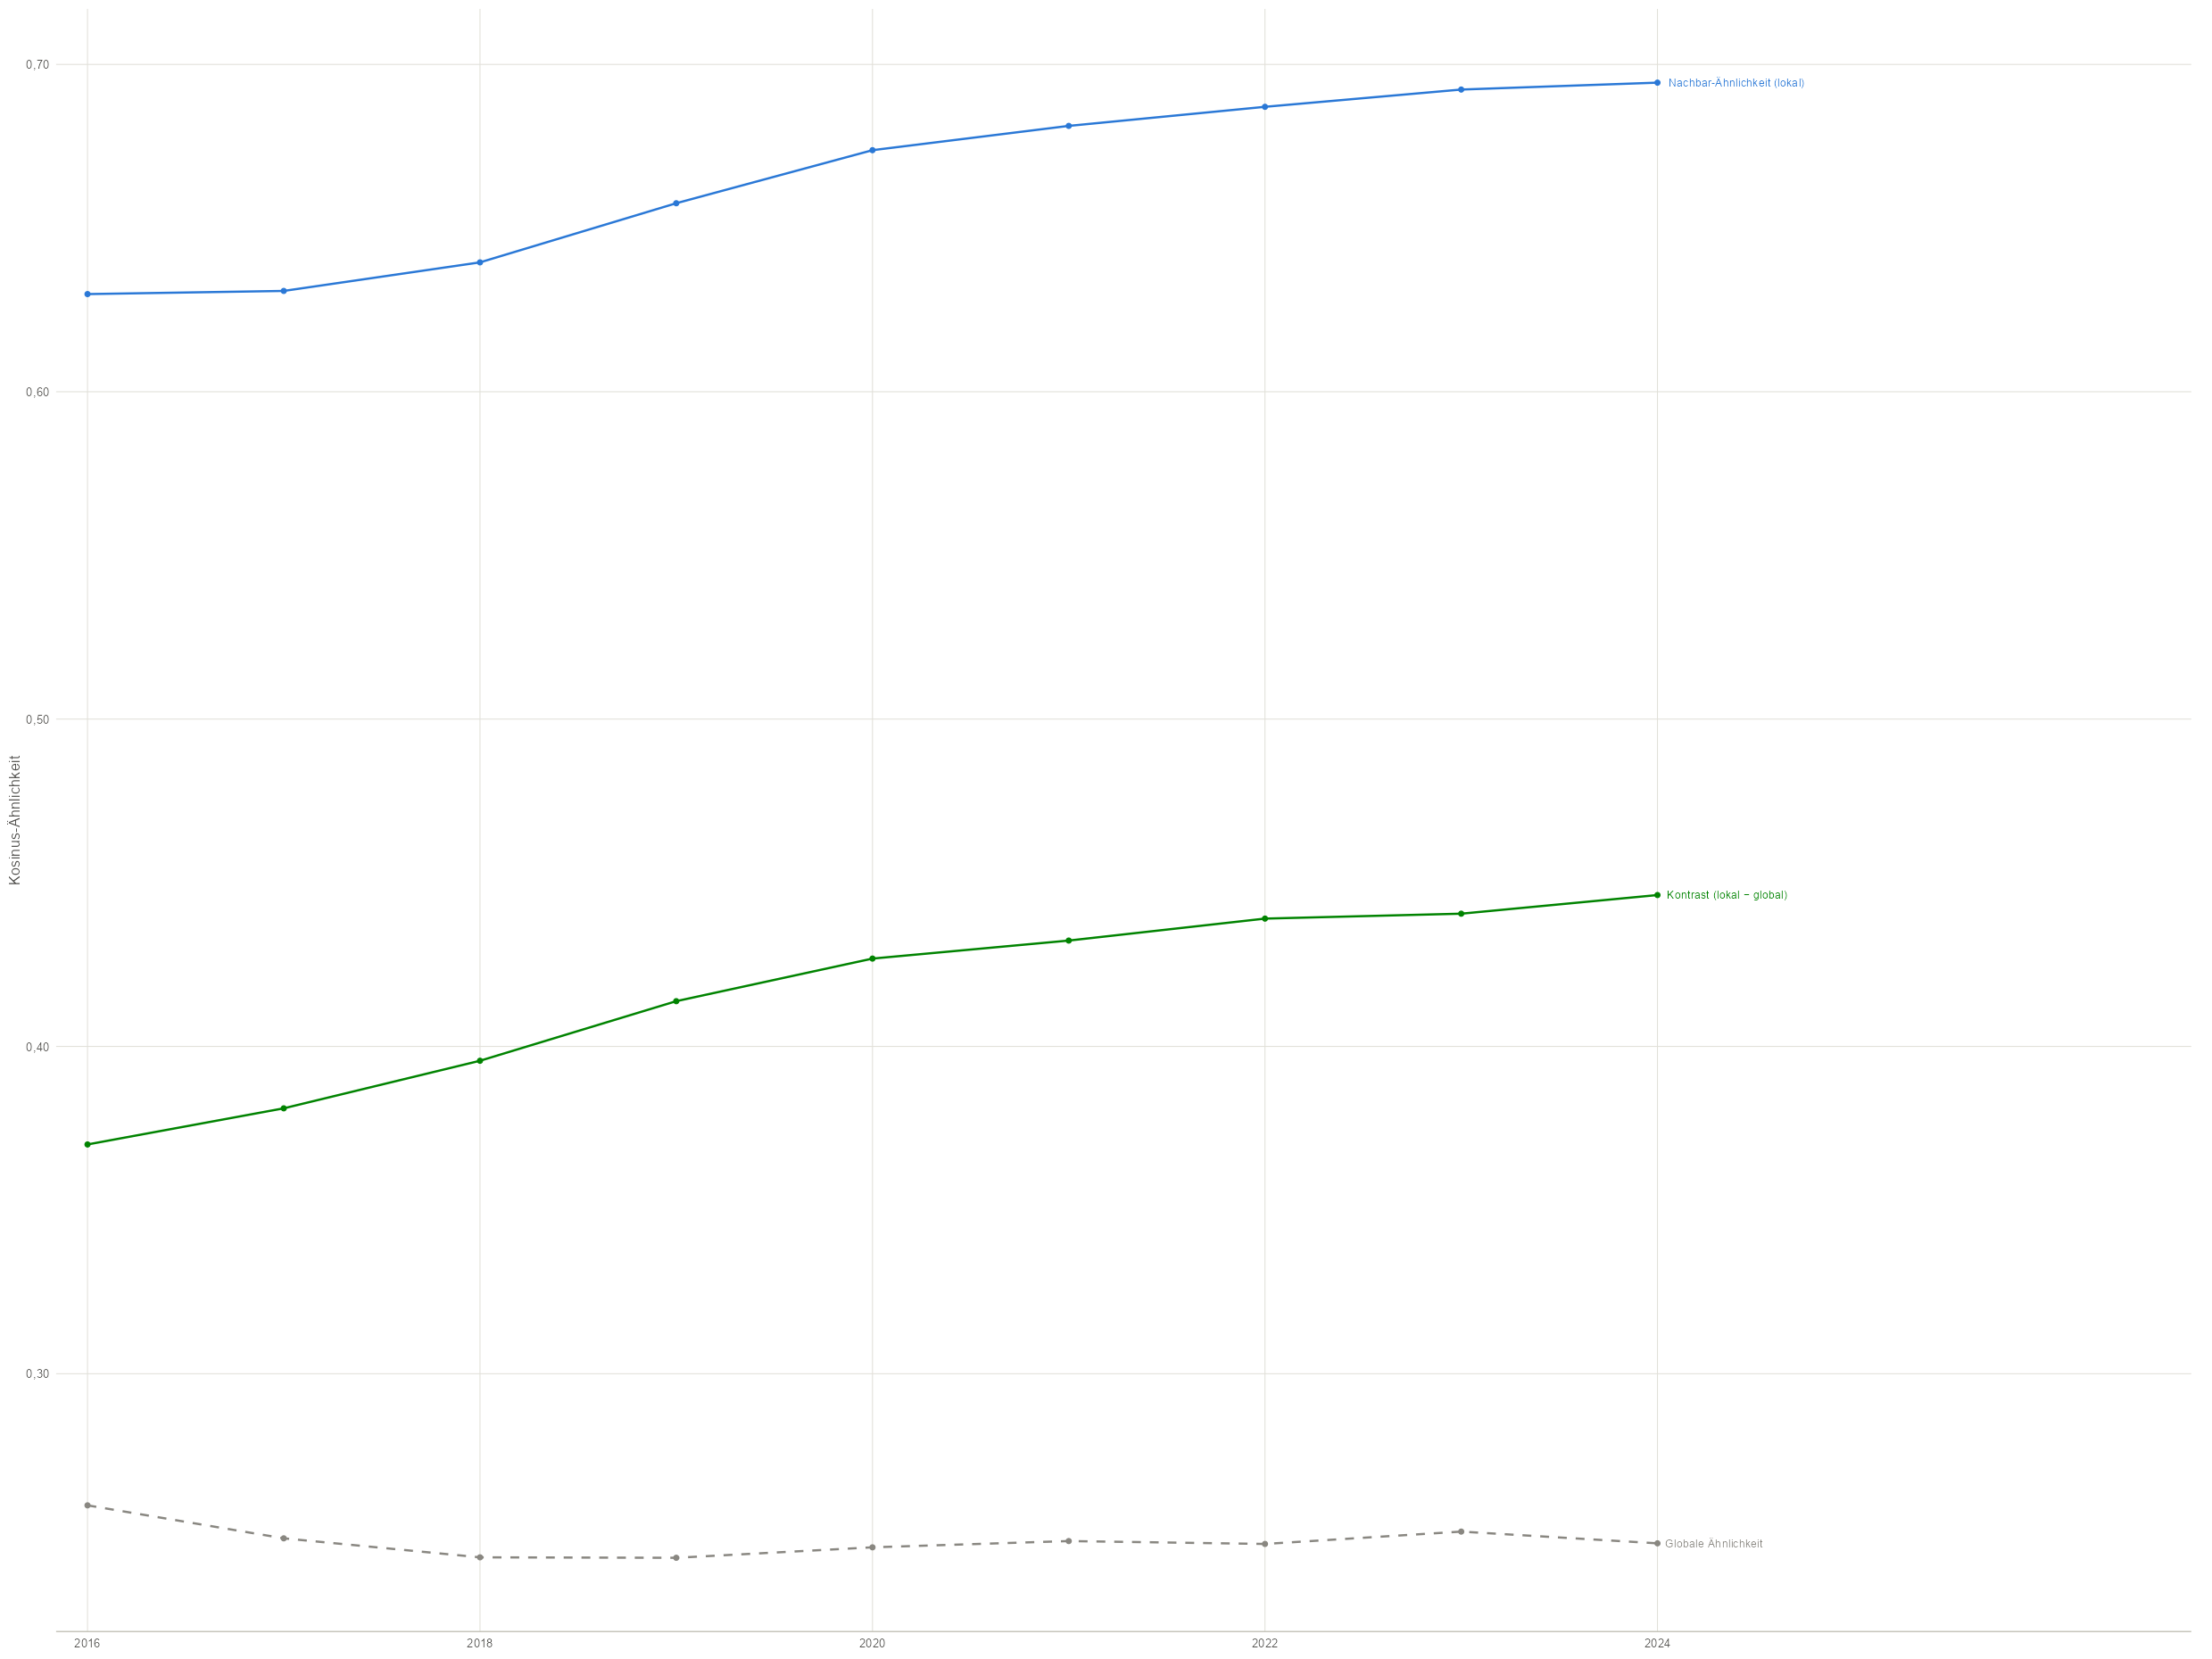

In [4]:
# ff1_geo_full.csv ist die exakte Rechnung über alle Vektorpaare und eine
# Eingabedatei, kein Erzeugnis dieser Pipeline. Die Stichprobenfassung in
# ff1_geometrie.csv trifft sie auf drei Nachkommastellen.
geo <- read_csv(file.path(PROJ, "ff1_geo_full.csv"), show_col_types = FALSE)

reihen <- c(mean_nn     = "Nachbar-Ähnlichkeit (lokal)",
            kontrast    = "Kontrast (lokal − global)",
            mean_global = "Globale Ähnlichkeit")

lang <- geo |>
  select(jahr, mean_nn, kontrast, mean_global) |>
  pivot_longer(-jahr, names_to = "reihe", values_to = "wert") |>
  mutate(reihe = factor(reihen[reihe], levels = unname(reihen)))

p_kontrast <- ggplot(lang, aes(jahr, wert, colour = reihe)) +
  geom_line(aes(linetype = reihe), linewidth = 0.7) +
  geom_point(size = 1.3) +
  geom_text(data = lang |> group_by(reihe) |> slice_max(jahr, n = 1) |> ungroup(),
            aes(label = reihe), hjust = -0.08, size = 2.7, show.legend = FALSE) +
  scale_colour_manual(values = setNames(c(BLAU, GRUEN, GRAU), unname(reihen))) +
  scale_linetype_manual(values = c("solid", "solid", "dashed")) +
  scale_x_continuous(breaks = seq(2016, 2024, 2), expand = expansion(mult = c(0.02, 0.34))) +
  scale_y_continuous(labels = scales::label_number(accuracy = 0.01, decimal.mark = ",")) +
  labs(x = NULL, y = "Kosinus-Ähnlichkeit") +
  theme_ma() + theme(legend.position = "none")

sichern(p_kontrast, "ff1_abb2_kontrast")
p_kontrast

## FF2

  -> ff2_abb1a_eta2_fix (pdf + png)


Warning message:
Using ragg device as default. Ignoring `type` and `antialias` arguments 


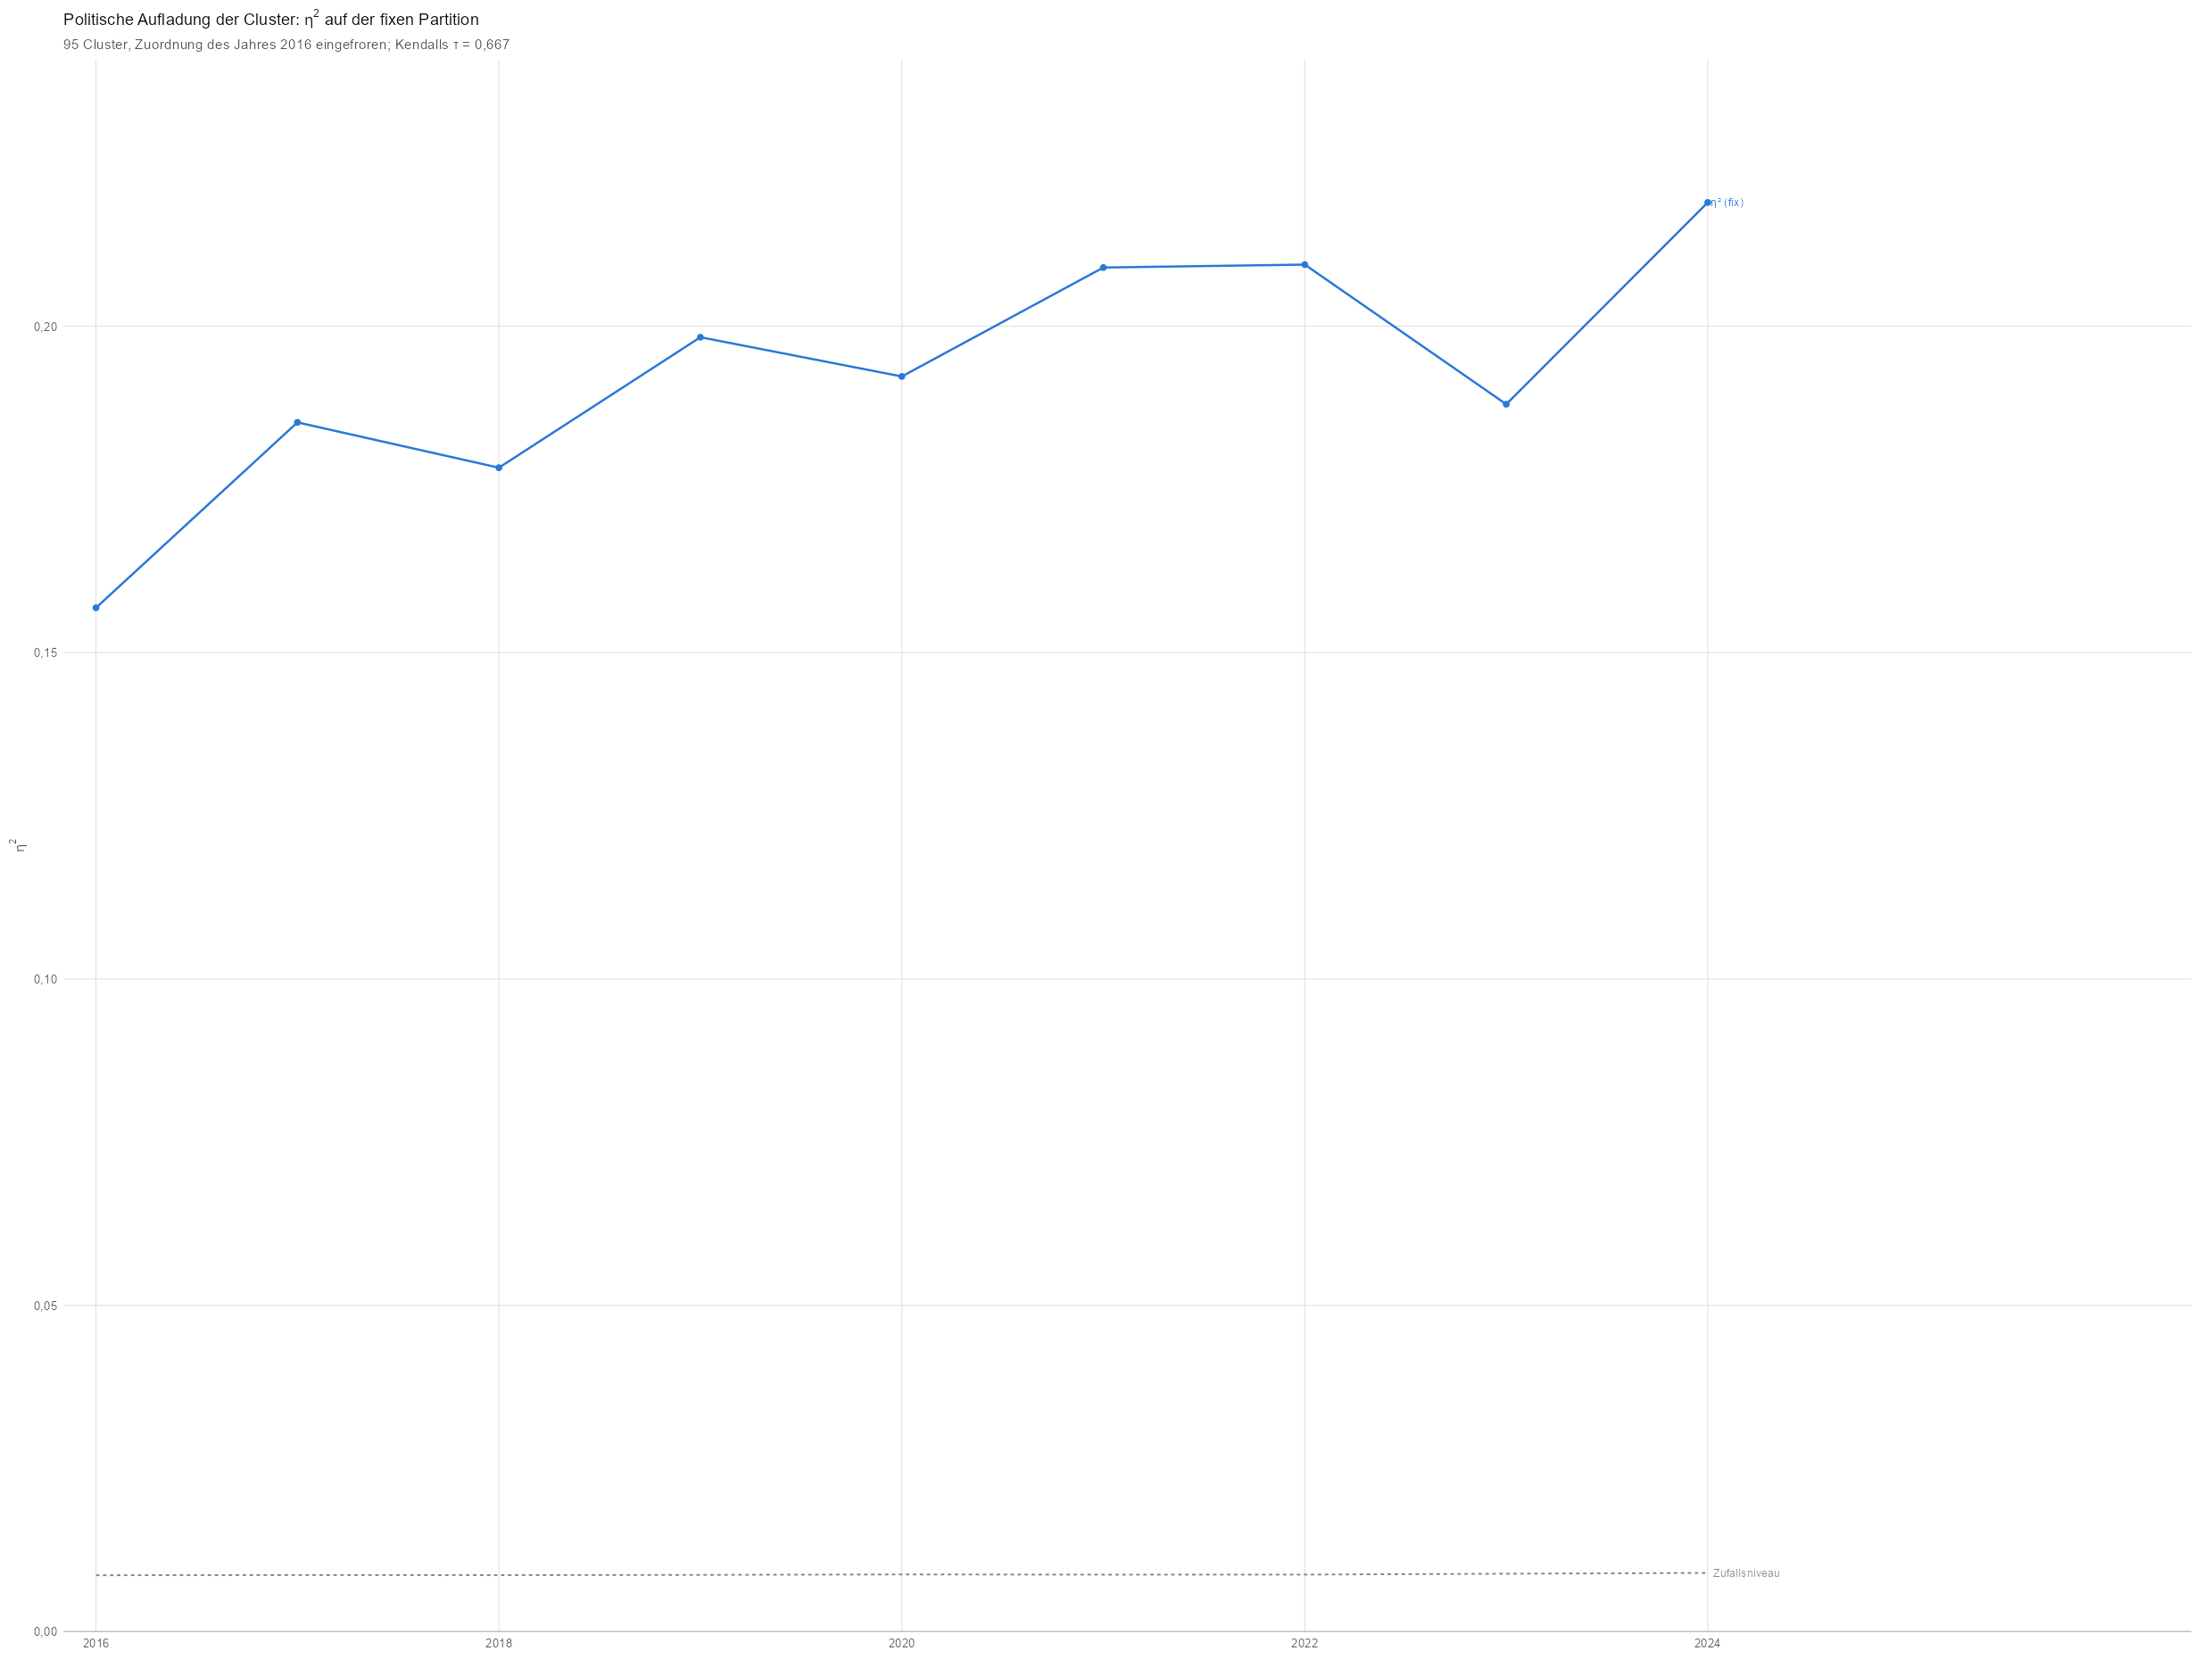

In [5]:
z_gew <- lies("ff2_zerlegung_gewichtet.csv")
nullp <- lies("ff2_eta2_null_perm.csv")

d_fix  <- tibble(jahr = z_gew$jahr, wert = z_gew$eta2)
d_null <- tibble(jahr = nullp$jahr, wert = nullp$eta2_null)

abb1a <- ggplot(mapping = aes(jahr, wert)) +
  geom_line(data = d_null, colour = GRAU, linetype = "22", linewidth = 0.55) +
  reflabel(d_null, "Zufallsniveau") +
  geom_line(data = d_fix, colour = BLAU, linewidth = 0.7) +
  geom_point(data = d_fix, colour = BLAU, size = 1.5) +
  geom_text(data = slice_max(d_fix, jahr), aes(label = "η² (fix)"),
            hjust = -0.10, size = 2.7, colour = BLAU) +
  scale_y_continuous(labels = komma, limits = c(0, NA), expand = expansion(mult = c(0, 0.10))) +
  jahre_achse +
  labs(title = expression(paste("Politische Aufladung der Cluster: ", eta^2,
                                " auf der fixen Partition")),
       subtitle = uz(sprintf("95 Cluster, Zuordnung des Jahres 2016 eingefroren; Kendalls τ = %s",
                             fmt(tau_von("eta2_fixed_voll"), 3))),
       x = NULL, y = expression(eta^2)) +
  theme_ma() + theme(legend.position = "none")

sichern(abb1a, "ff2_abb1a_eta2_fix")
abb1a

  -> ff2_abb1b_eta2 (pdf + png)


Warning message:
Using ragg device as default. Ignoring `type` and `antialias` arguments 


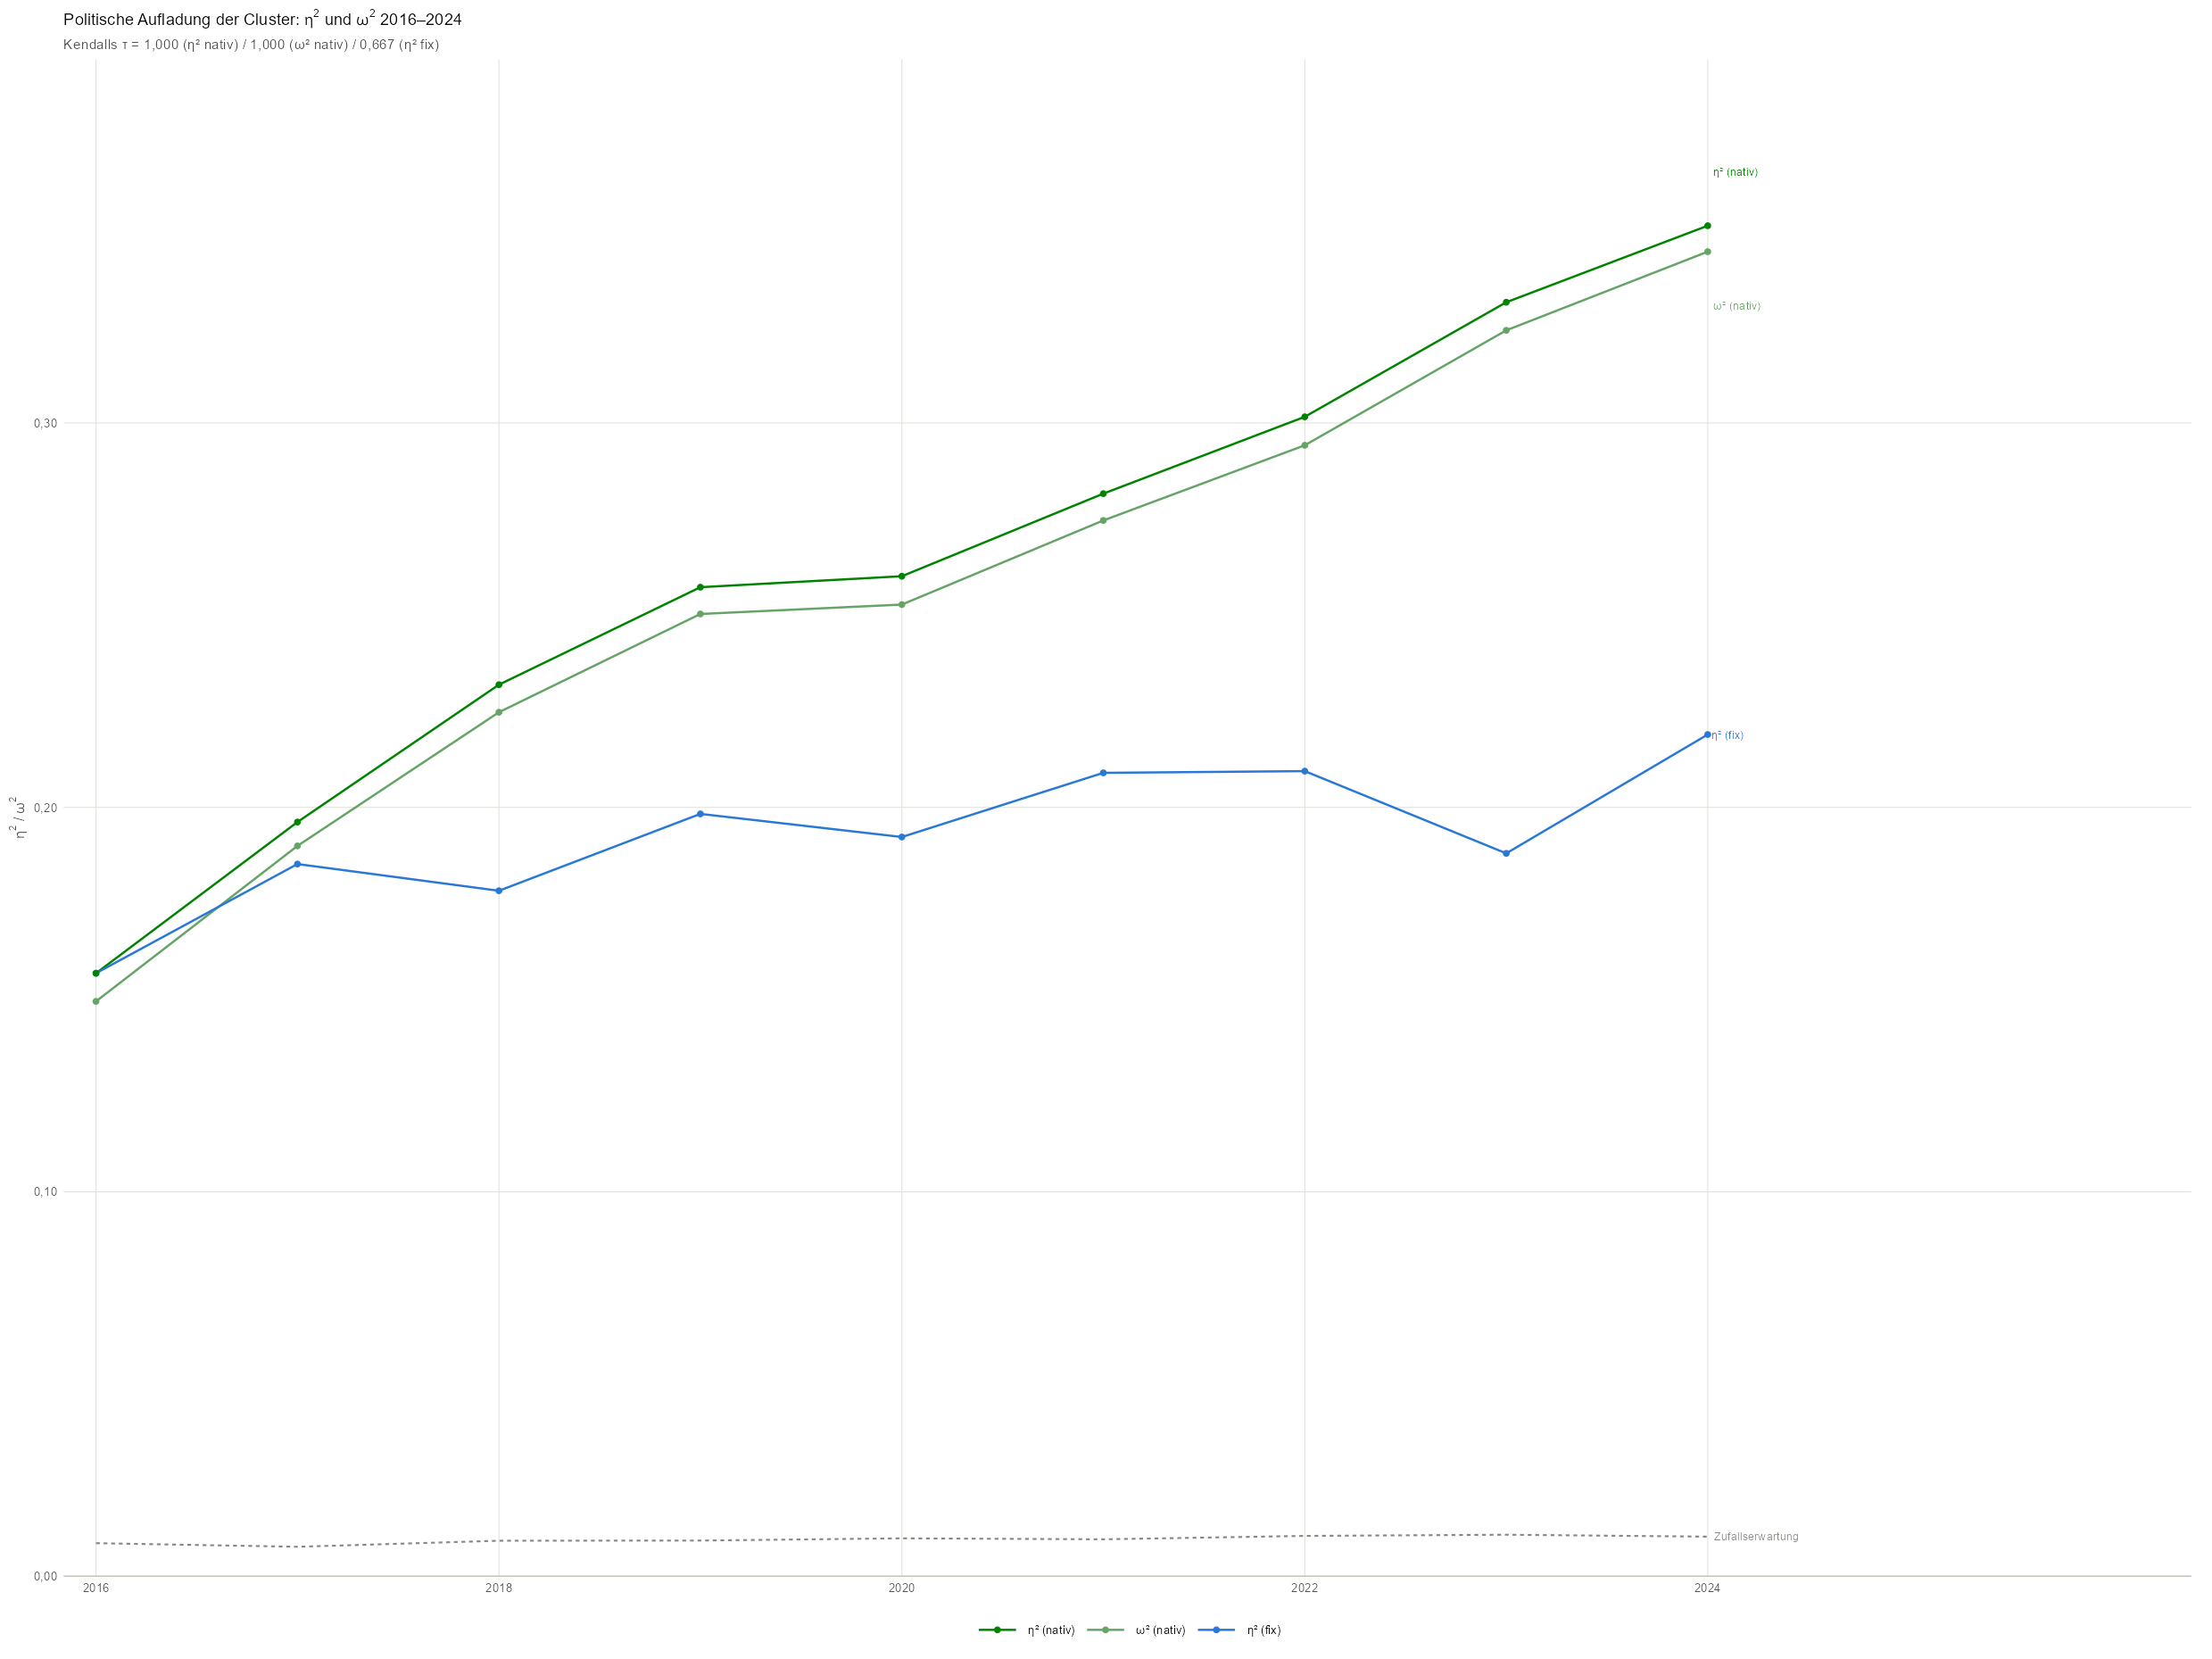

In [6]:
nat <- lies("ff2_native_frei.csv")

d1 <- bind_rows(
  tibble(jahr = z_gew$jahr, wert = z_gew$eta2,             reihe = "η² (fix)"),
  tibble(jahr = nat$jahr,   wert = nat$eta2_native_frei,   reihe = "η² (nativ)"),
  tibble(jahr = nat$jahr,   wert = nat$omega2_native_frei, reihe = "ω² (nativ)"),
  tibble(jahr = nat$jahr,   wert = nat$bench,              reihe = "Zufallserwartung")
) |>
  mutate(reihe = factor(reihe, levels = c("η² (nativ)", "ω² (nativ)",
                                          "η² (fix)", "Zufallserwartung")))

d1_serien <- filter(d1, reihe != "Zufallserwartung")
d1_ref    <- filter(d1, reihe == "Zufallserwartung")

abb1 <- ggplot(mapping = aes(jahr, wert)) +
  geom_line(data = d1_ref, colour = GRAU, linetype = "22", linewidth = 0.6) +
  geom_line(data = d1_serien, aes(colour = reihe), linewidth = 0.7) +
  geom_point(data = d1_serien, aes(colour = reihe), size = 1.5) +
  reflabel(d1_ref, "Zufallserwartung") +
  # eta² und omega² nativ liegen am Endpunkt nur 0,006 auseinander
  endlabel(d1_serien, "jahr", "wert", "reihe",
           nudge = c("η² (nativ)" = 0.014, "ω² (nativ)" = -0.014)) +
  scale_colour_manual(values = c("η² (nativ)" = GRUEN,
                                 "ω² (nativ)" = "#66a366",
                                 "η² (fix)"   = BLAU)) +
  scale_y_continuous(labels = komma, limits = c(0, NA), expand = expansion(mult = c(0, 0.08))) +
  jahre_achse +
  labs(title = expression(paste("Politische Aufladung der Cluster: ", eta^2, " und ",
                                omega^2, " 2016–2024")),
       subtitle = uz(sprintf("Kendalls τ = %s (η² nativ) / %s (ω² nativ) / %s (η² fix)",
                             fmt(tau_von("eta2_native_lifestyle"), 3),
                             fmt(tau_von("omega2_native_lifestyle"), 3),
                             fmt(tau_von("eta2_fixed_voll"), 3))),
       x = NULL, y = expression(paste(eta^2, " / ", omega^2))) +
  theme_ma()

sichern(abb1, "ff2_abb1b_eta2")
abb1

  -> ff2_abb2_zerlegung (pdf + png)


Warning message:
Using ragg device as default. Ignoring `type` and `antialias` arguments 


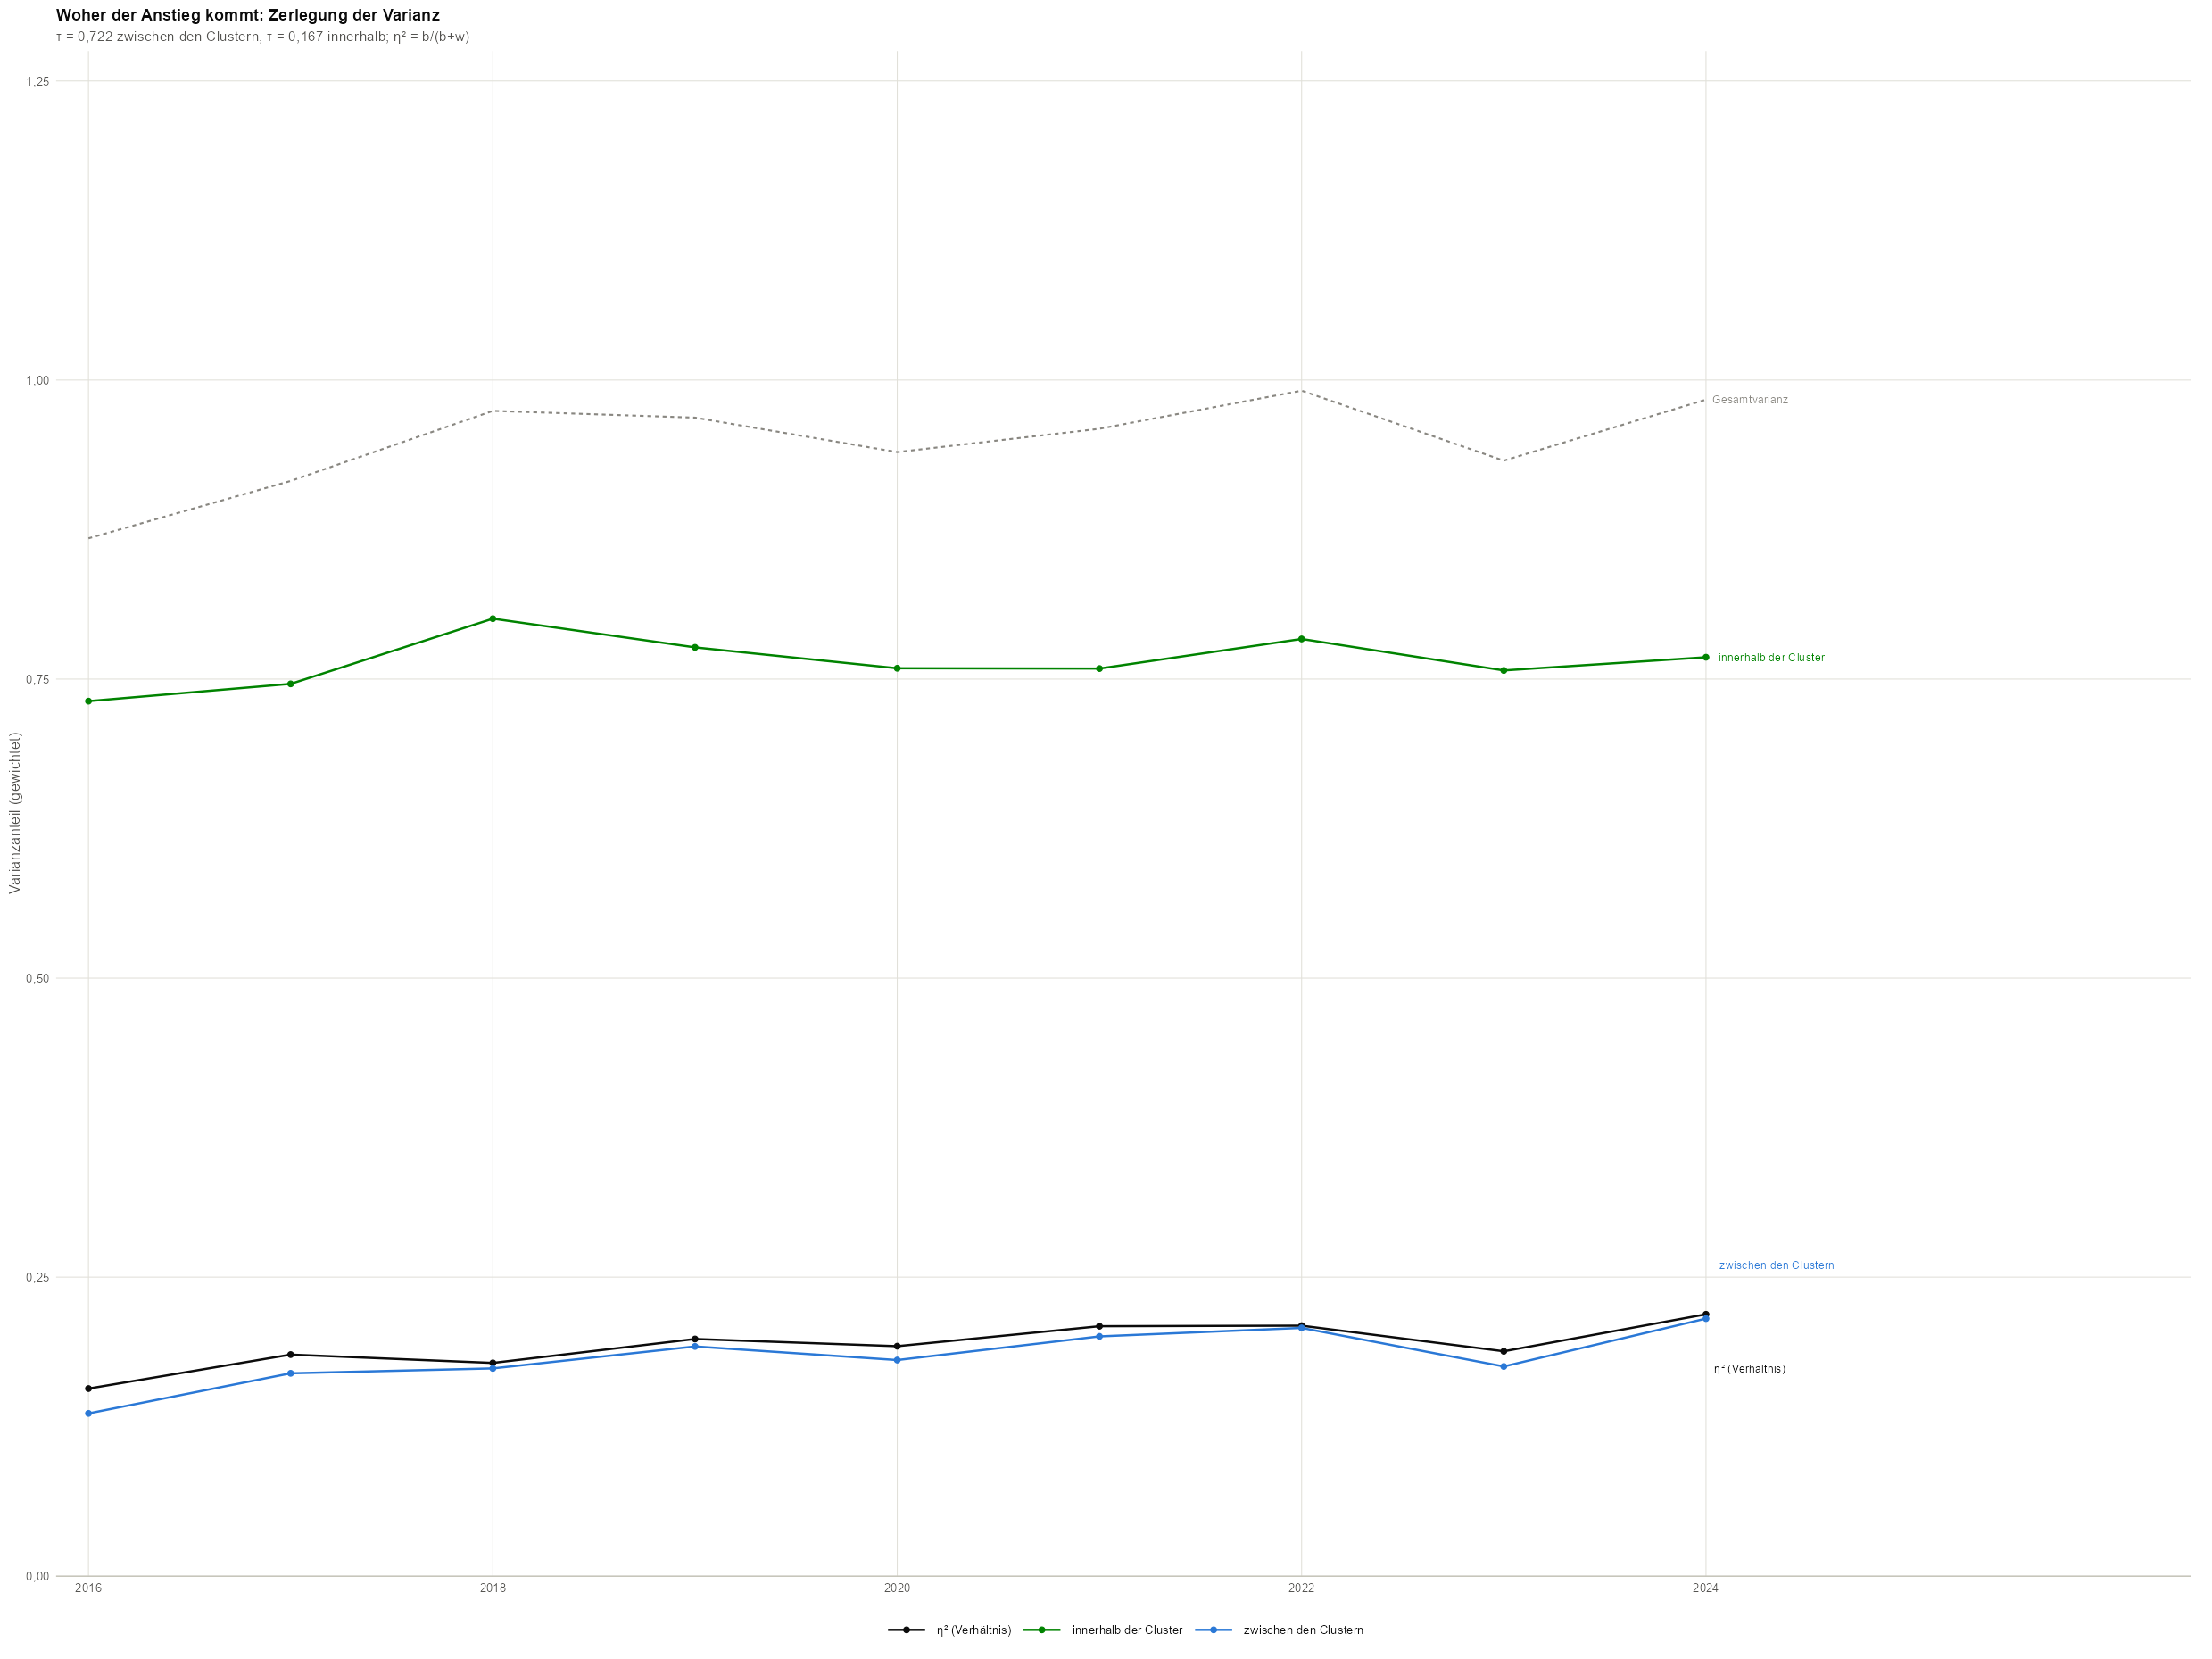

In [7]:
d2 <- bind_rows(
  tibble(jahr = z_gew$jahr, wert = z_gew$eta2,        reihe = "η² (Verhältnis)"),
  tibble(jahr = z_gew$jahr, wert = z_gew$between_gew, reihe = "zwischen den Clustern"),
  tibble(jahr = z_gew$jahr, wert = z_gew$within_gew,  reihe = "innerhalb der Cluster"),
  tibble(jahr = z_gew$jahr, wert = z_gew$gesamt_var,  reihe = "Gesamtvarianz")
) |>
  mutate(reihe = factor(reihe, levels = c("η² (Verhältnis)", "innerhalb der Cluster",
                                          "zwischen den Clustern", "Gesamtvarianz")))

d2_serien <- filter(d2, reihe != "Gesamtvarianz")
d2_ref    <- filter(d2, reihe == "Gesamtvarianz")

abb2 <- ggplot(mapping = aes(jahr, wert)) +
  geom_line(data = d2_ref, colour = GRAU, linetype = "22", linewidth = 0.6) +
  geom_line(data = d2_serien, aes(colour = reihe), linewidth = 0.7) +
  geom_point(data = d2_serien, aes(colour = reihe), size = 1.5) +
  reflabel(d2_ref, "Gesamtvarianz") +
  endlabel(d2_serien, "jahr", "wert", "reihe",
           nudge = c("η² (Verhältnis)" = -0.045, "zwischen den Clustern" = 0.045)) +
  scale_colour_manual(values = c("η² (Verhältnis)"       = TINTE,
                                 "innerhalb der Cluster" = GRUEN,
                                 "zwischen den Clustern" = BLAU)) +
  scale_y_continuous(labels = komma, limits = c(0, 1.25), expand = expansion(mult = c(0, 0.02))) +
  jahre_achse +
  labs(title = "Woher der Anstieg kommt: Zerlegung der Varianz",
       subtitle = uz(sprintf("τ = %s zwischen den Clustern, τ = %s innerhalb; η² = b/(b+w)",
                             fmt(tau_von("between_gew"), 3), fmt(tau_von("within_gew"), 3))),
       x = NULL, y = "Varianzanteil (gewichtet)") +
  theme_ma()

sichern(abb2, "ff2_abb2_zerlegung")
abb2

  -> ff2_abb3_moran_ksweep (pdf + png)


Warning message:
Using ragg device as default. Ignoring `type` and `antialias` arguments 


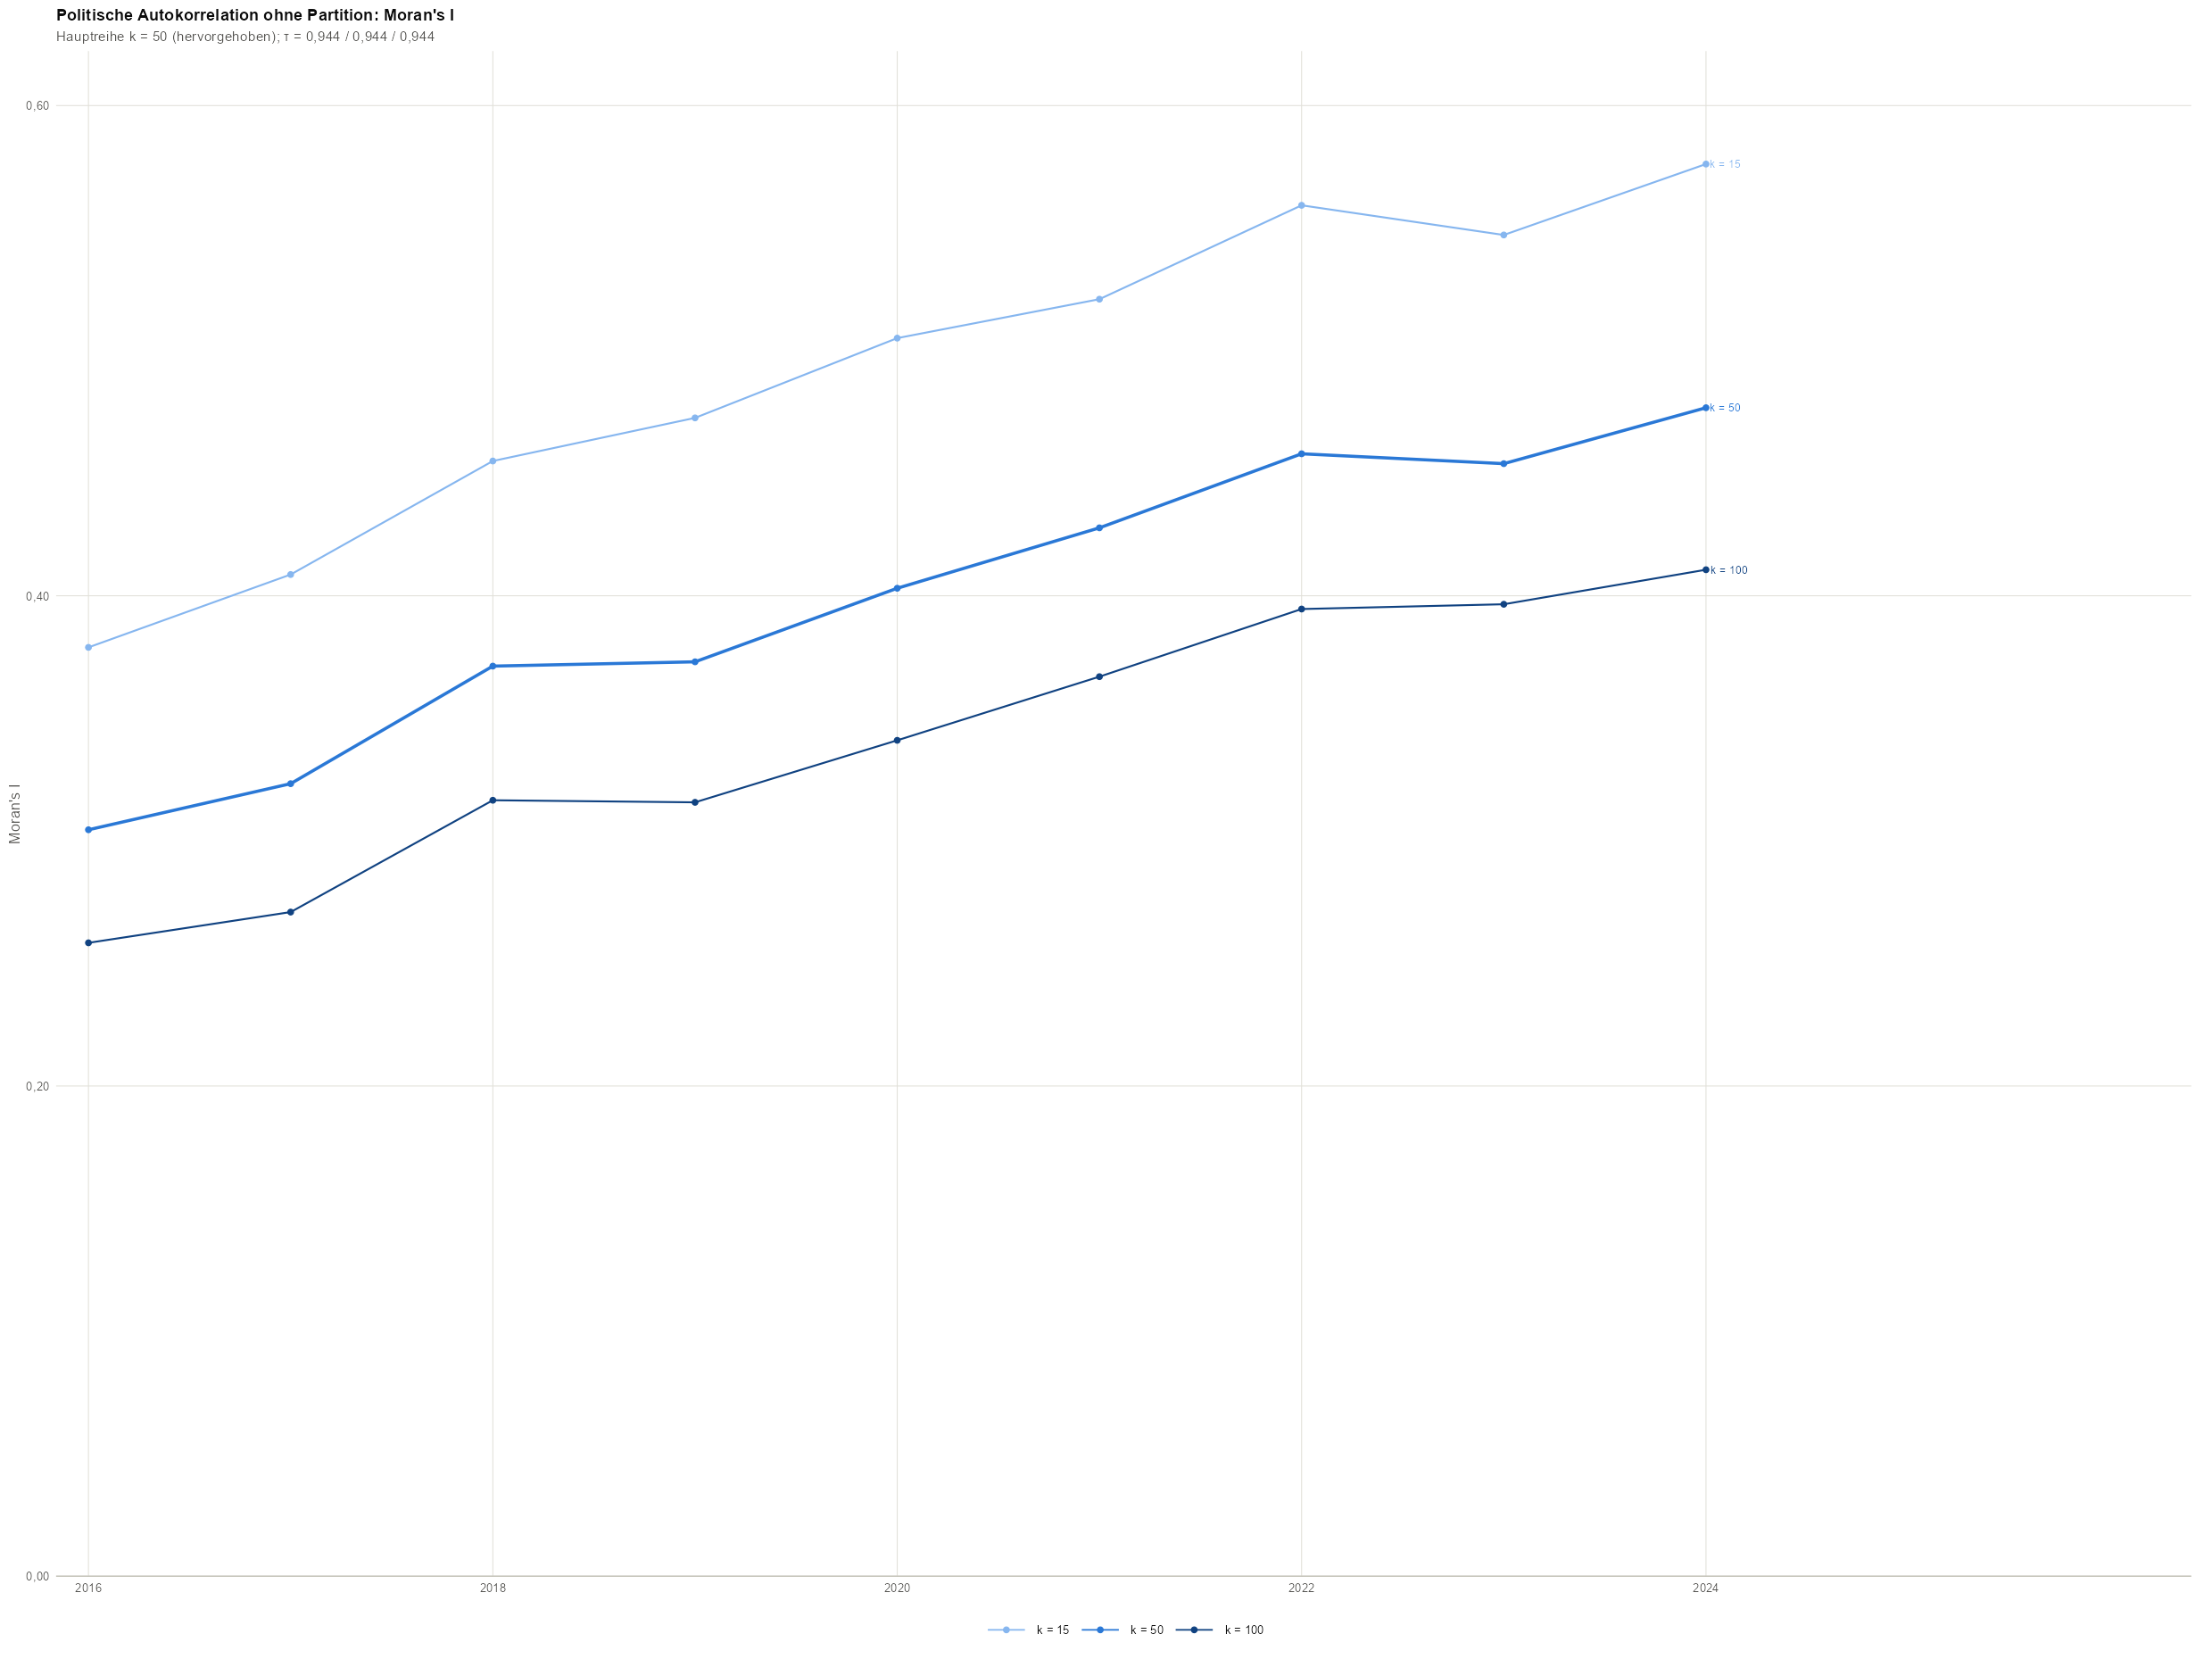

In [8]:
ks <- lies("ff2_moran_ksweep_lifestyle.csv") |>
  mutate(reihe = factor(paste0("k = ", k), levels = c("k = 15", "k = 50", "k = 100")))

abb3 <- ggplot(ks, aes(jahr, moran_I, colour = reihe)) +
  geom_line(aes(linewidth = reihe)) +
  geom_point(size = 1.5) +
  endlabel(ks, "jahr", "moran_I", "reihe") +
  scale_colour_manual(values = setNames(RAMPE, c("k = 15", "k = 50", "k = 100"))) +
  scale_linewidth_manual(values = c("k = 15" = 0.6, "k = 50" = 1.0, "k = 100" = 0.6),
                         guide = "none") +
  scale_y_continuous(labels = komma, limits = c(0, NA), expand = expansion(mult = c(0, 0.08))) +
  jahre_achse +
  labs(title = "Politische Autokorrelation ohne Partition: Moran's I",
       subtitle = uz(sprintf("Hauptreihe k = 50 (hervorgehoben); τ = %s / %s / %s",
                             fmt(tau_von("moran_ls_k15",  trends_k), 3),
                             fmt(tau_von("moran_ls_k50",  trends_k), 3),
                             fmt(tau_von("moran_ls_k100", trends_k), 3))),
       x = NULL, y = "Moran's I") +
  theme_ma()

sichern(abb3, "ff2_abb3_moran_ksweep")
abb3

  -> ff2_abb3b_moran_threshold (pdf + png)


Warning message:
Using ragg device as default. Ignoring `type` and `antialias` arguments 


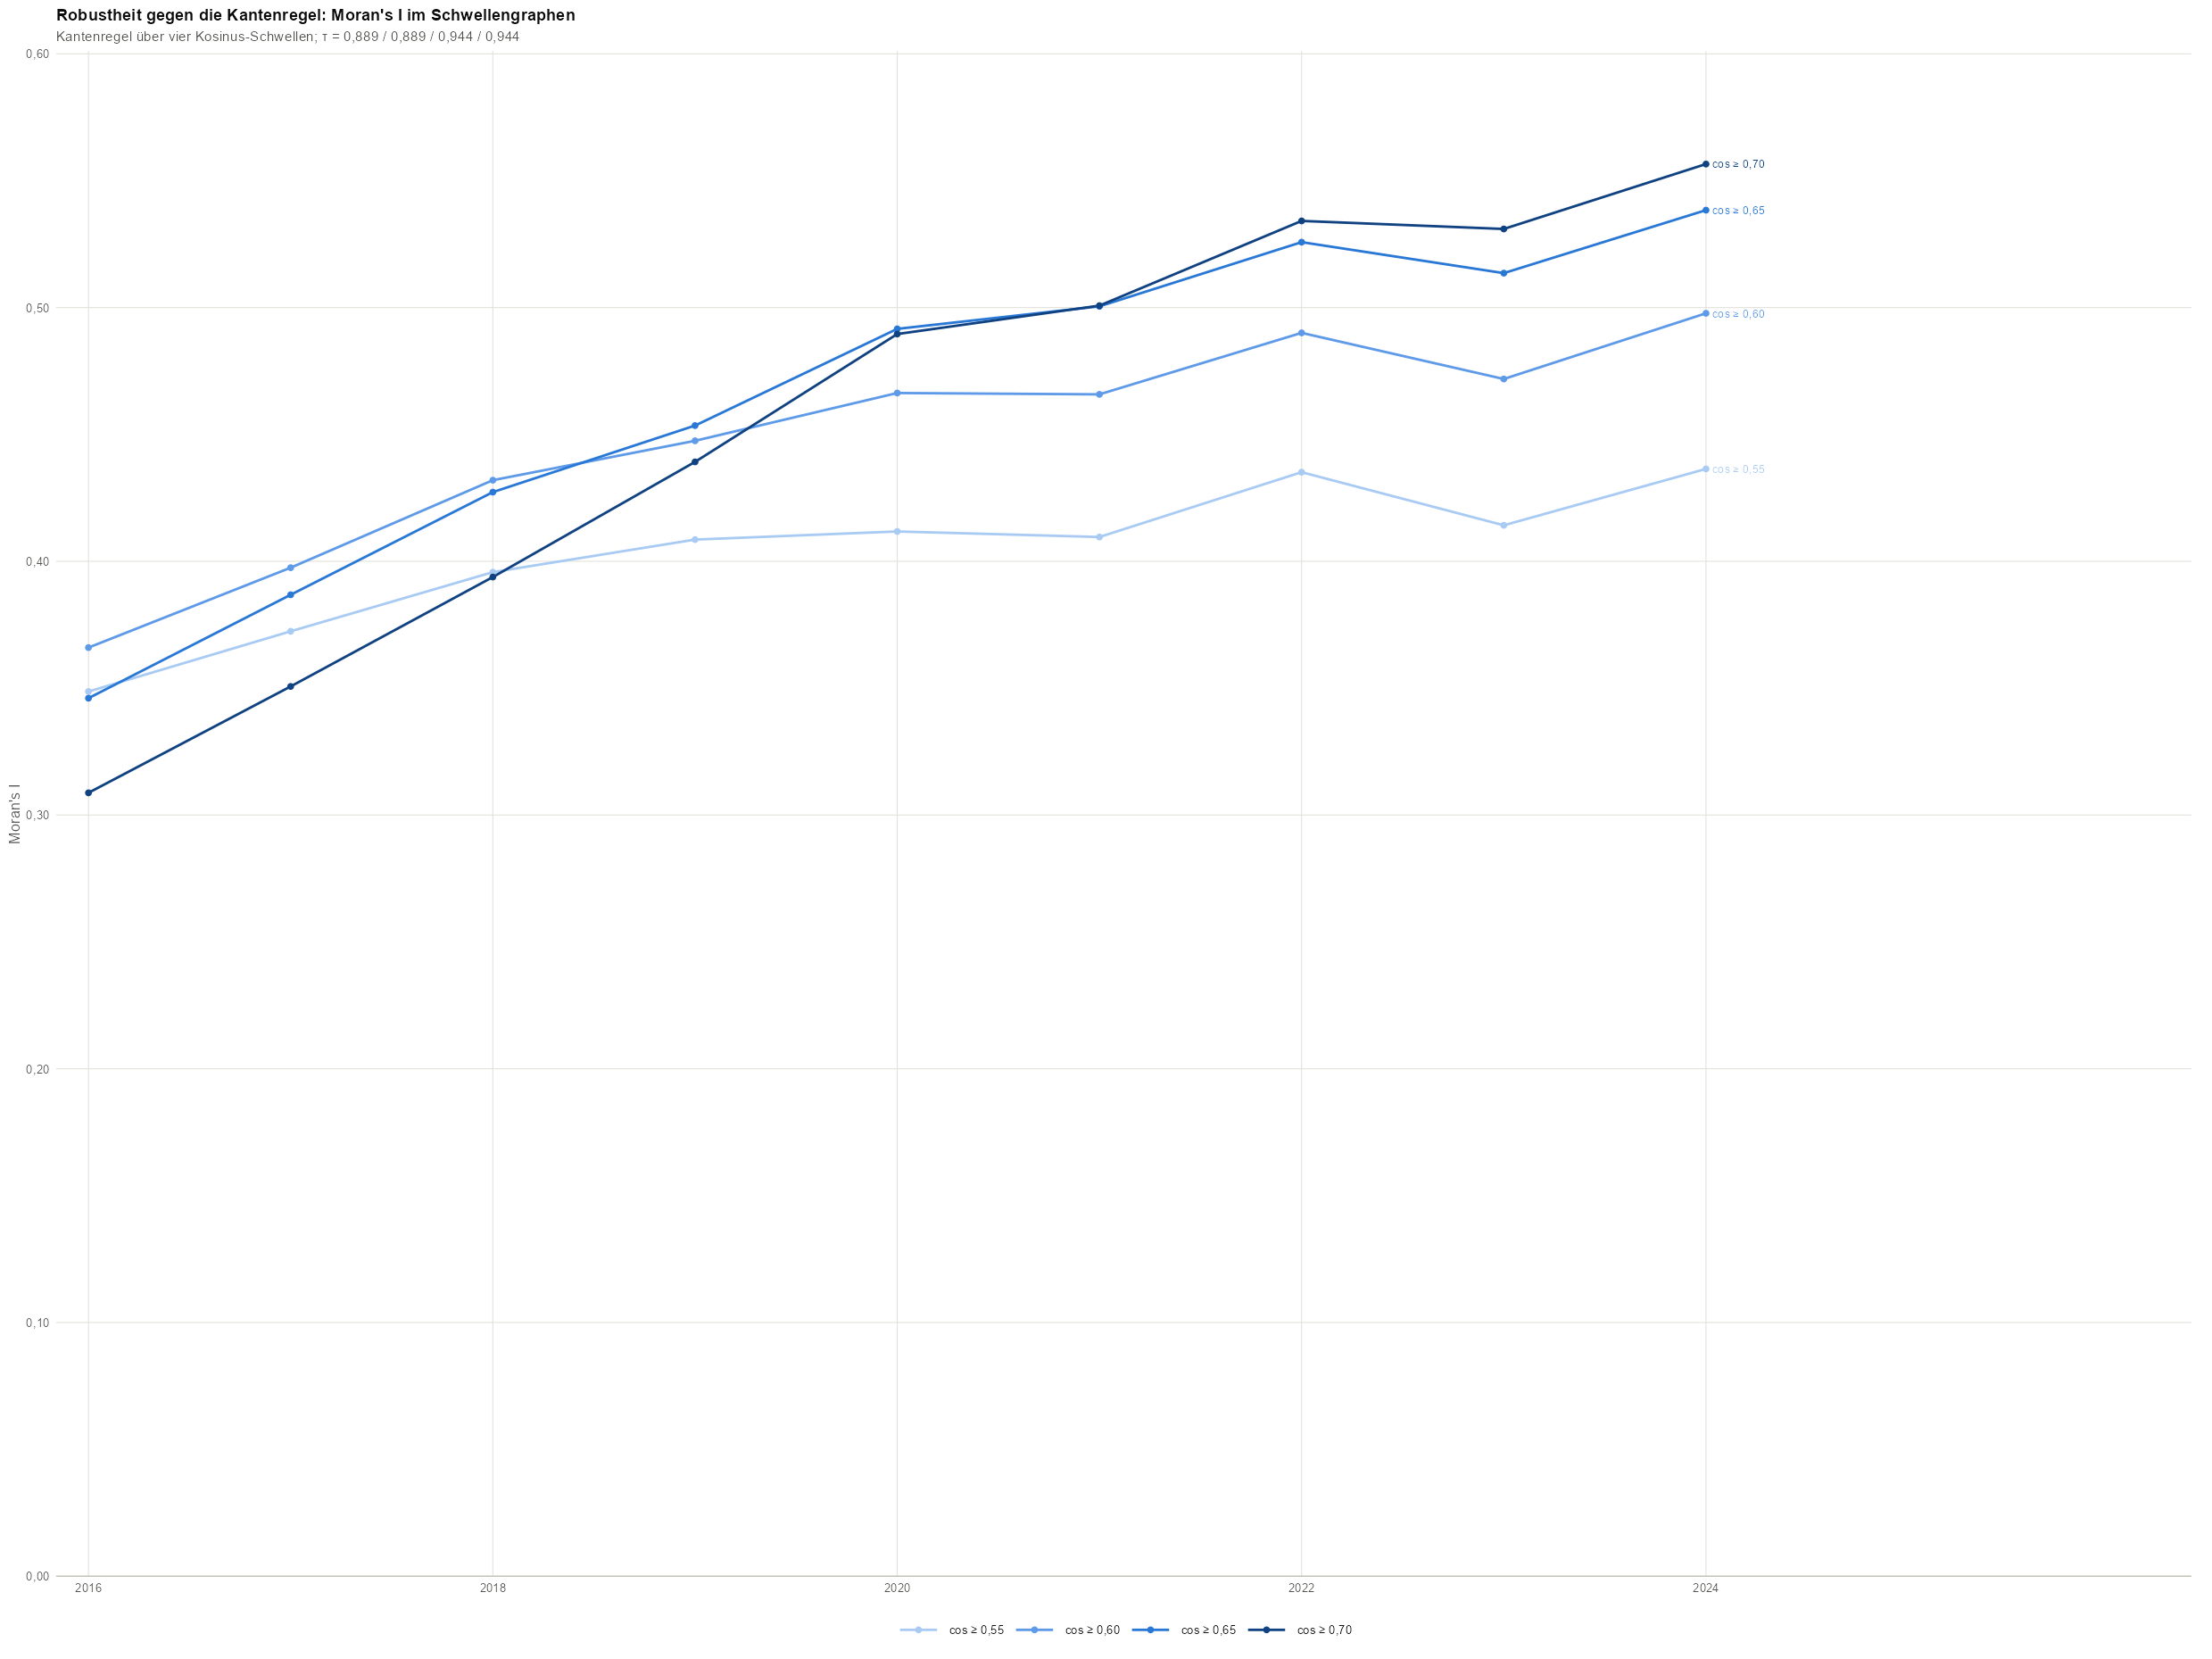

In [9]:
th <- lies("ff2_moran_threshold_lifestyle.csv") |>
  mutate(reihe = factor(sprintf("cos ≥ %s", fmt(tau, 2)),
                        levels = sprintf("cos ≥ %s", fmt(c(0.55, 0.60, 0.65, 0.70), 2))))

abb3b <- ggplot(th, aes(jahr, moran_I, colour = reihe)) +
  geom_line(linewidth = 0.8) +
  geom_point(size = 1.5) +
  # 0,65 und 0,70 enden 0,019 auseinander, die Labels fallen sonst zusammen
  endlabel(th, "jahr", "moran_I", "reihe",
           nudge = c("cos ≥ 0,70" = 0.012, "cos ≥ 0,65" = -0.012)) +
  scale_colour_manual(values = setNames(RAMPE4, levels(th$reihe))) +
  scale_y_continuous(labels = komma, limits = c(0, NA), expand = expansion(mult = c(0, 0.08))) +
  jahre_achse +
  labs(title = "Robustheit gegen die Kantenregel: Moran's I im Schwellengraphen",
       subtitle = uz(sprintf("Kantenregel über vier Kosinus-Schwellen; τ = %s / %s / %s / %s",
                             fmt(tau_von("moran_threshold_ls_tau055", trends_th), 3),
                             fmt(tau_von("moran_threshold_ls_tau060", trends_th), 3),
                             fmt(tau_von("moran_threshold_ls_tau065", trends_th), 3),
                             fmt(tau_von("moran_threshold_ls_tau070", trends_th), 3))),
       x = NULL, y = "Moran's I") +
  theme_ma()

sichern(abb3b, "ff2_abb3b_moran_threshold")
abb3b

  -> ff2_abb4a_altbestand (pdf + png)


Warning message:
Using ragg device as default. Ignoring `type` and `antialias` arguments 


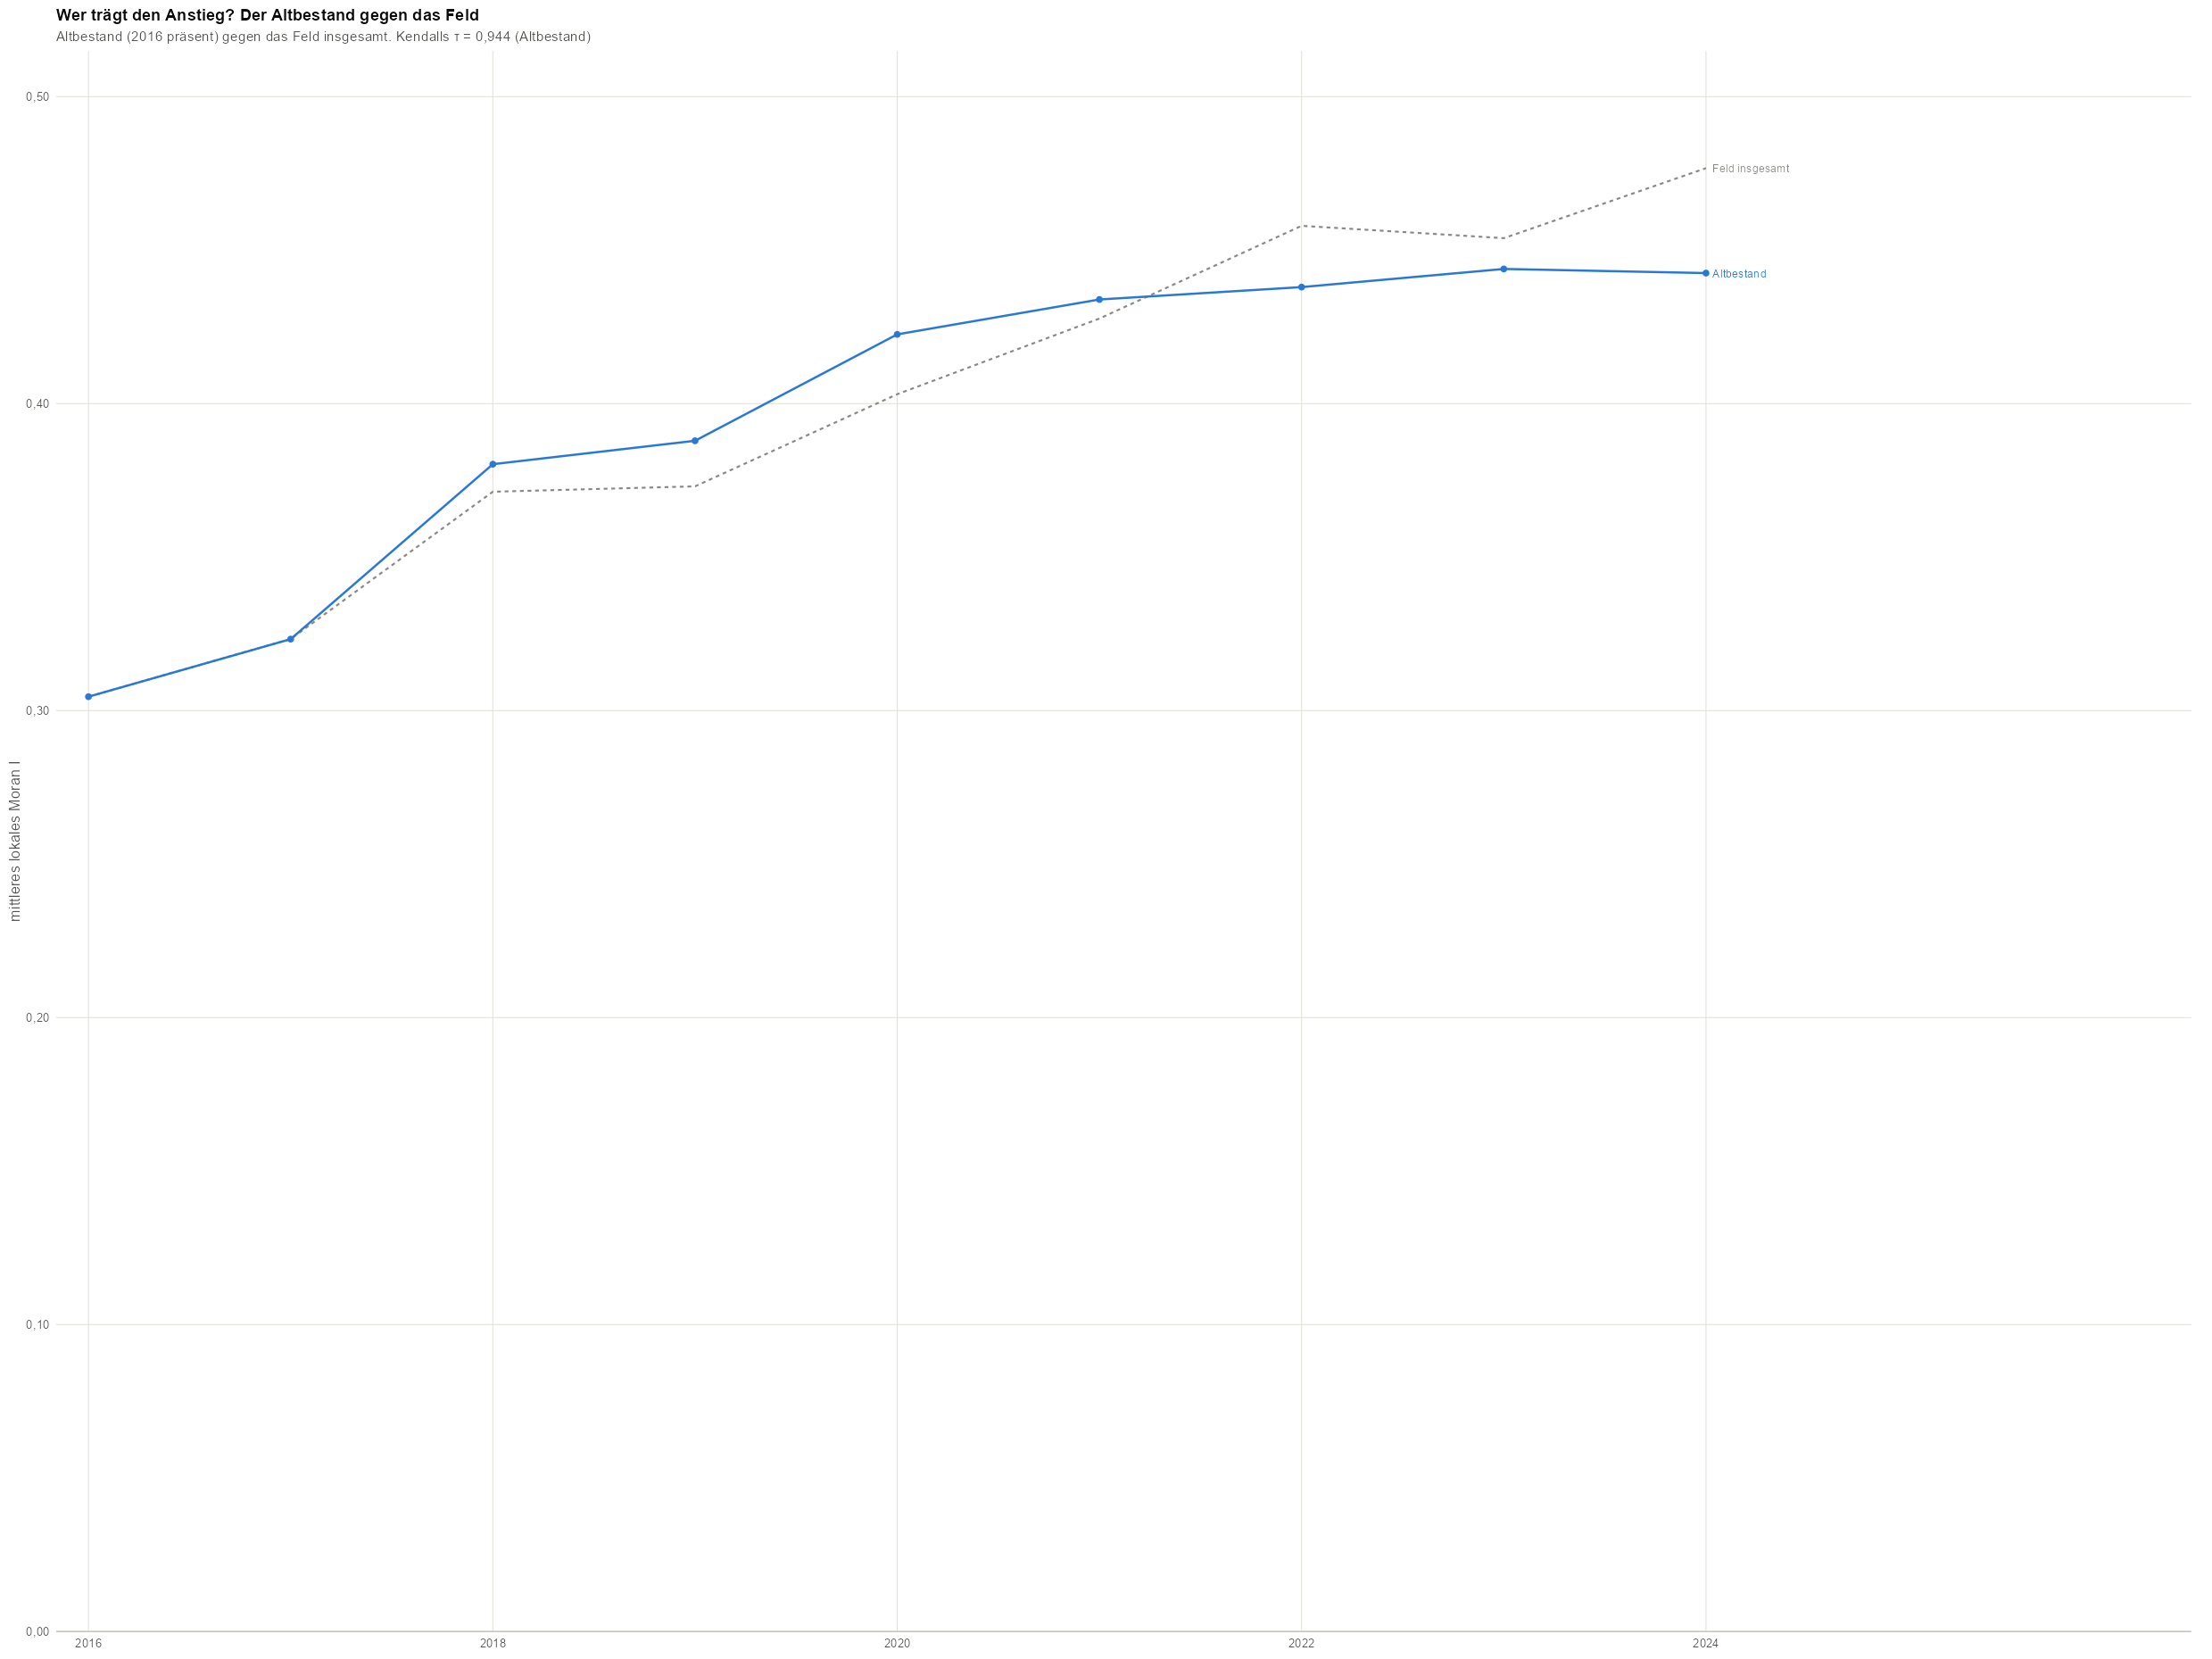

In [10]:
lok <- lies("ff2_moran_lokal.csv")
d4  <- bind_rows(tibble(jahr = lok$jahr, wert = lok$moran_alt,    reihe = "Altbestand"),
                 tibble(jahr = lok$jahr, wert = lok$moran_global, reihe = "Feld insgesamt")) |>
  filter(!is.na(wert))

abb4a <- ggplot(mapping = aes(jahr, wert)) +
  geom_line(data = filter(d4, reihe == "Feld insgesamt"), colour = GRAU,
            linetype = "22", linewidth = 0.6) +
  geom_line(data = filter(d4, reihe == "Altbestand"), aes(colour = reihe), linewidth = 0.7) +
  geom_point(data = filter(d4, reihe == "Altbestand"), aes(colour = reihe), size = 1.5) +
  reflabel(filter(d4, reihe == "Feld insgesamt"), "Feld insgesamt") +
  endlabel(filter(d4, reihe == "Altbestand"), "jahr", "wert", "reihe") +
  scale_colour_manual(values = c("Altbestand" = BLAU), guide = "none") +
  scale_y_continuous(labels = komma, limits = c(0, NA), expand = expansion(mult = c(0, 0.08))) +
  jahre_achse +
  labs(title = "Wer trägt den Anstieg? Der Altbestand gegen das Feld",
       subtitle = uz(sprintf(paste("Altbestand (2016 präsent) gegen das Feld insgesamt.",
                                   "Kendalls τ = %s (Altbestand)"),
                             fmt(tau_von("moran_altbestand"), 3))),
       x = NULL, y = "mittleres lokales Moran I") +
  theme_ma()

sichern(abb4a, "ff2_abb4a_altbestand")
abb4a

  -> ff2_abb4b_kohorten (pdf + png)


Warning message:
Using ragg device as default. Ignoring `type` and `antialias` arguments 


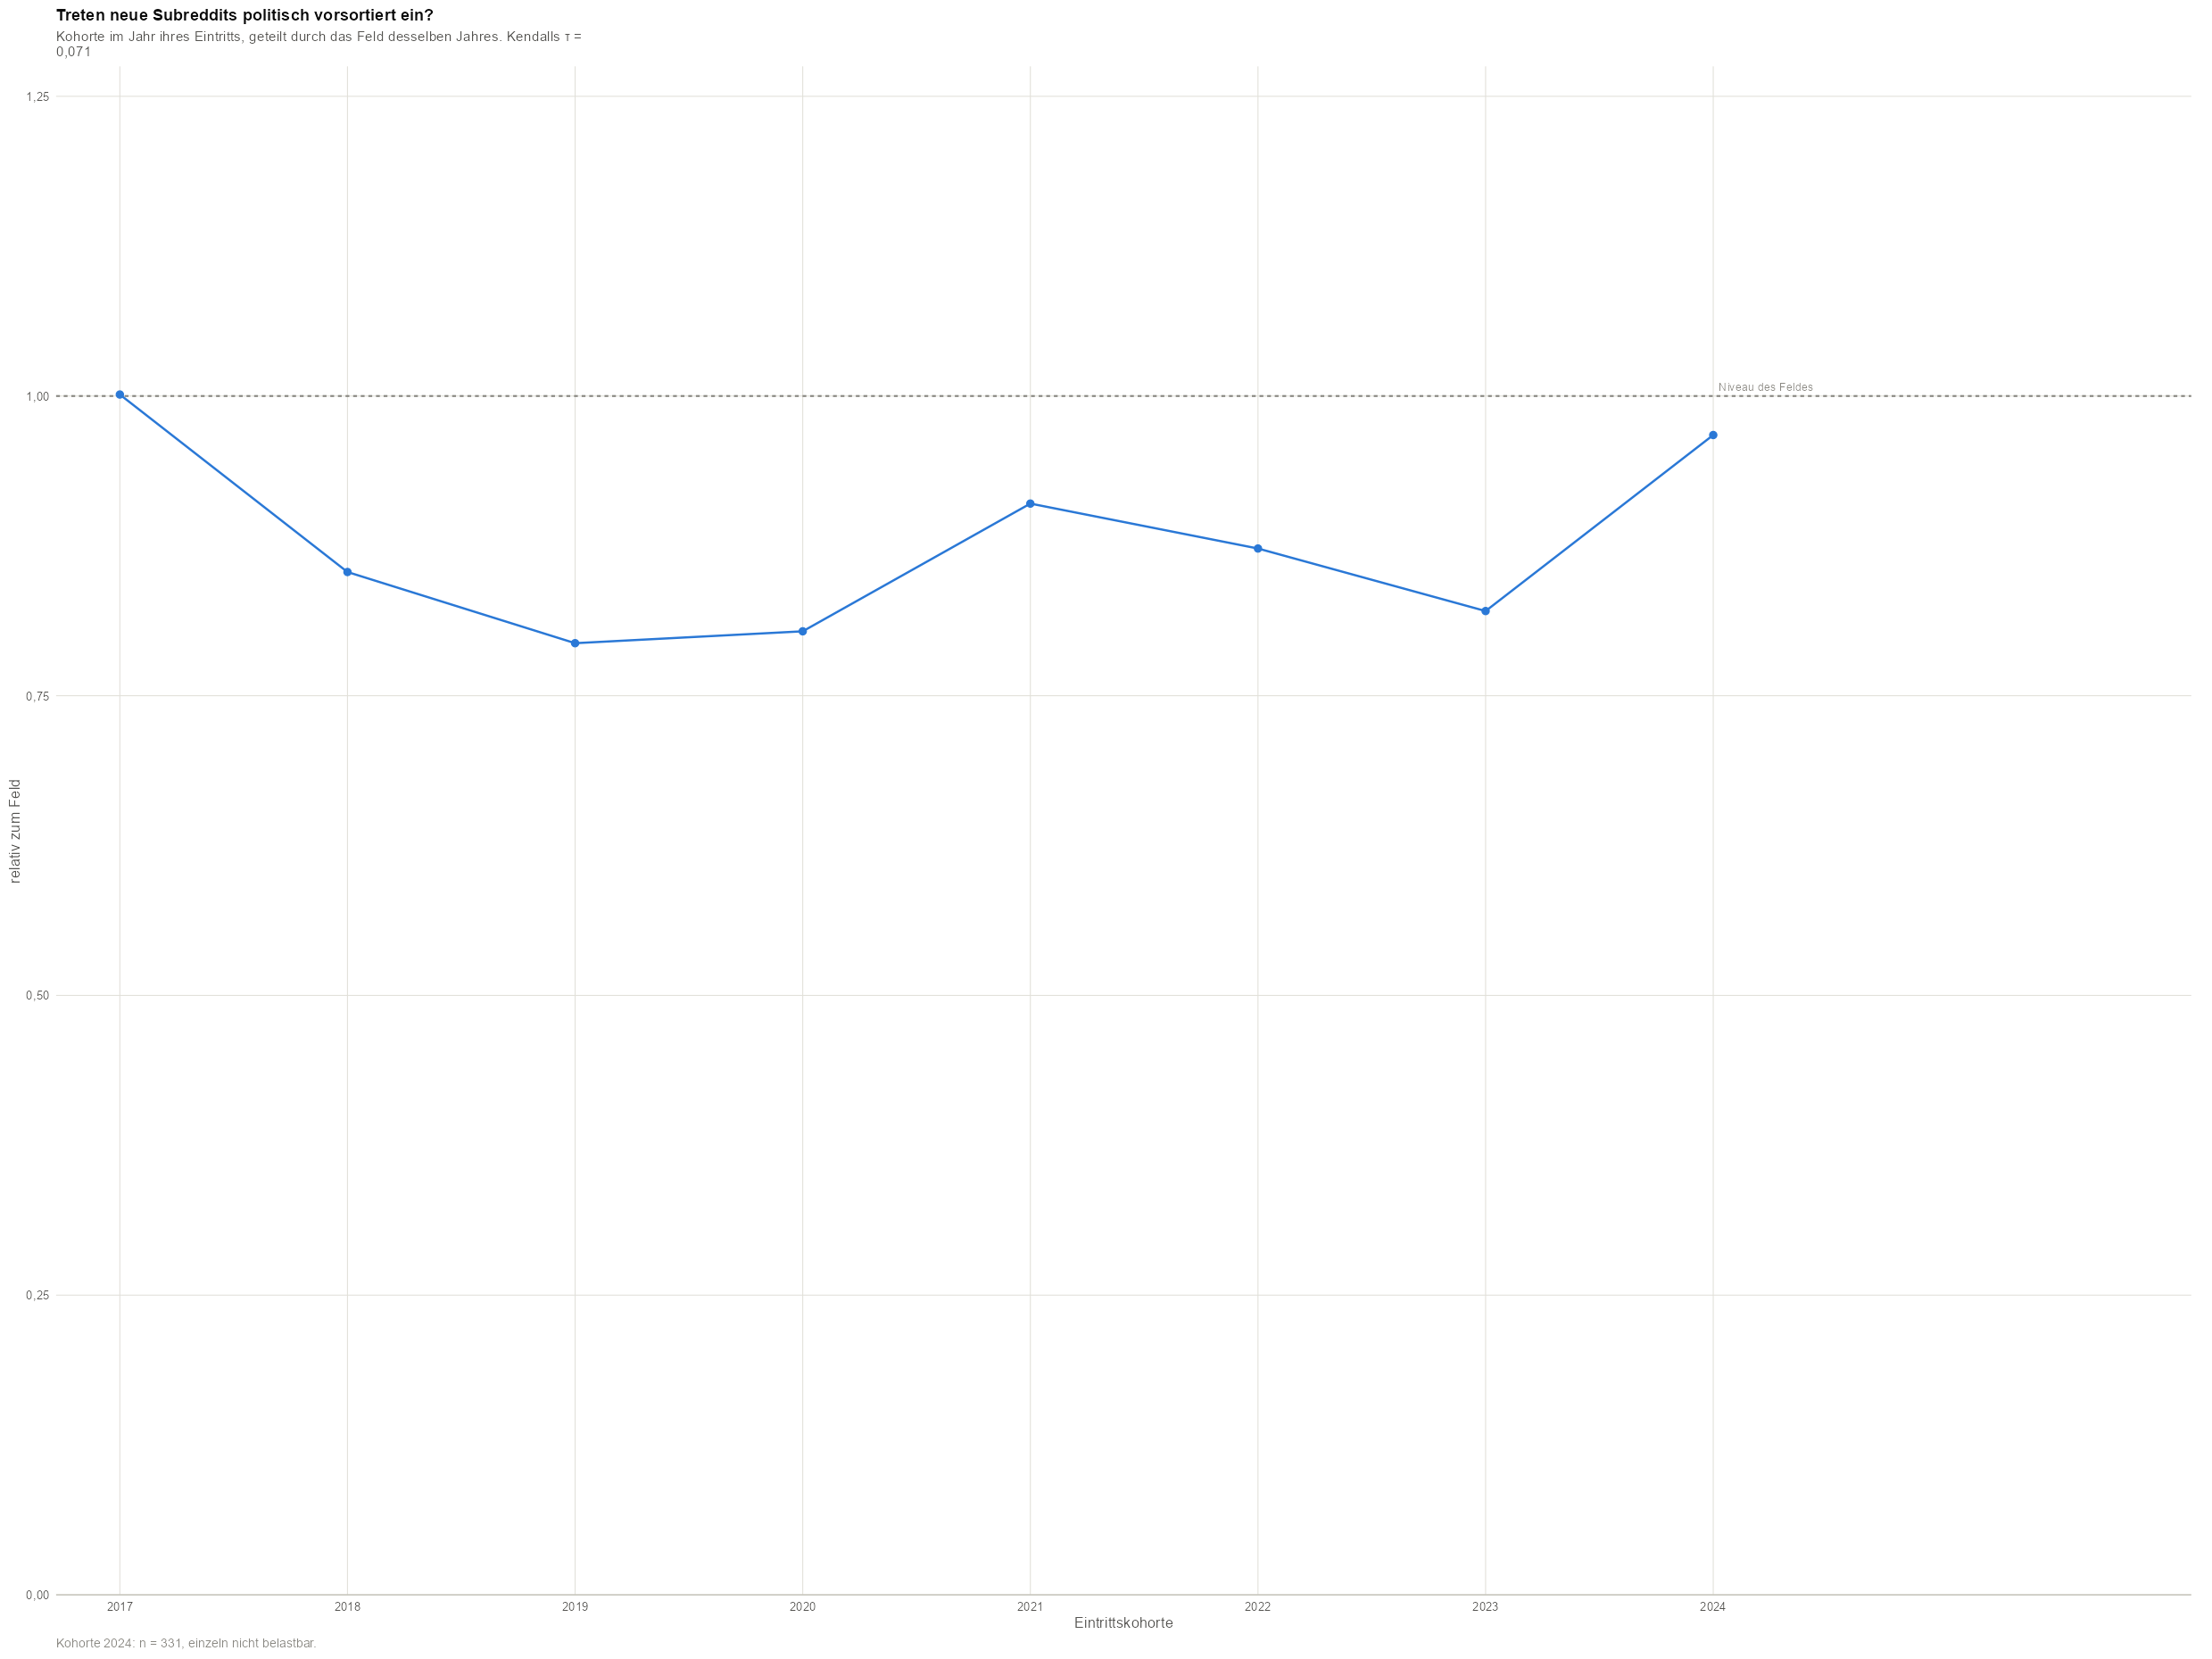

In [11]:
koh <- lies("ff2_moran_kohorten.csv") |> mutate(relativ = moran_kohorte / moran_global)

abb4b <- ggplot(koh, aes(kohorte, relativ)) +
  geom_hline(yintercept = 1, colour = GRAU, linetype = "22", linewidth = 0.6) +
  annotate("text", x = max(koh$kohorte), y = 1, label = "Niveau des Feldes",
           hjust = -0.06, vjust = -0.6, size = 2.7, colour = GRAU) +
  geom_line(colour = BLAU, linewidth = 0.7) +
  geom_point(colour = BLAU, size = 2) +
  scale_y_continuous(labels = komma, limits = c(0, 1.25), expand = expansion(mult = c(0, 0.02))) +
  scale_x_continuous(breaks = koh$kohorte, expand = expansion(mult = c(0.04, 0.30))) +
  labs(title = "Treten neue Subreddits politisch vorsortiert ein?",
       subtitle = uz(sprintf(paste("Kohorte im Jahr ihres Eintritts, geteilt durch das Feld",
                                   "desselben Jahres. Kendalls τ = %s"),
                             fmt(tau_von("kohorte_relativ_feld"), 3))),
       caption = paste0("Kohorte ", max(koh$kohorte), ": n = ",
                        koh$n_kohorte[which.max(koh$kohorte)], ", einzeln nicht belastbar."),
       x = "Eintrittskohorte", y = "relativ zum Feld") +
  theme_ma()

sichern(abb4b, "ff2_abb4b_kohorten")
abb4b

## FF3

  -> ff3_abb1_beitrag (pdf)


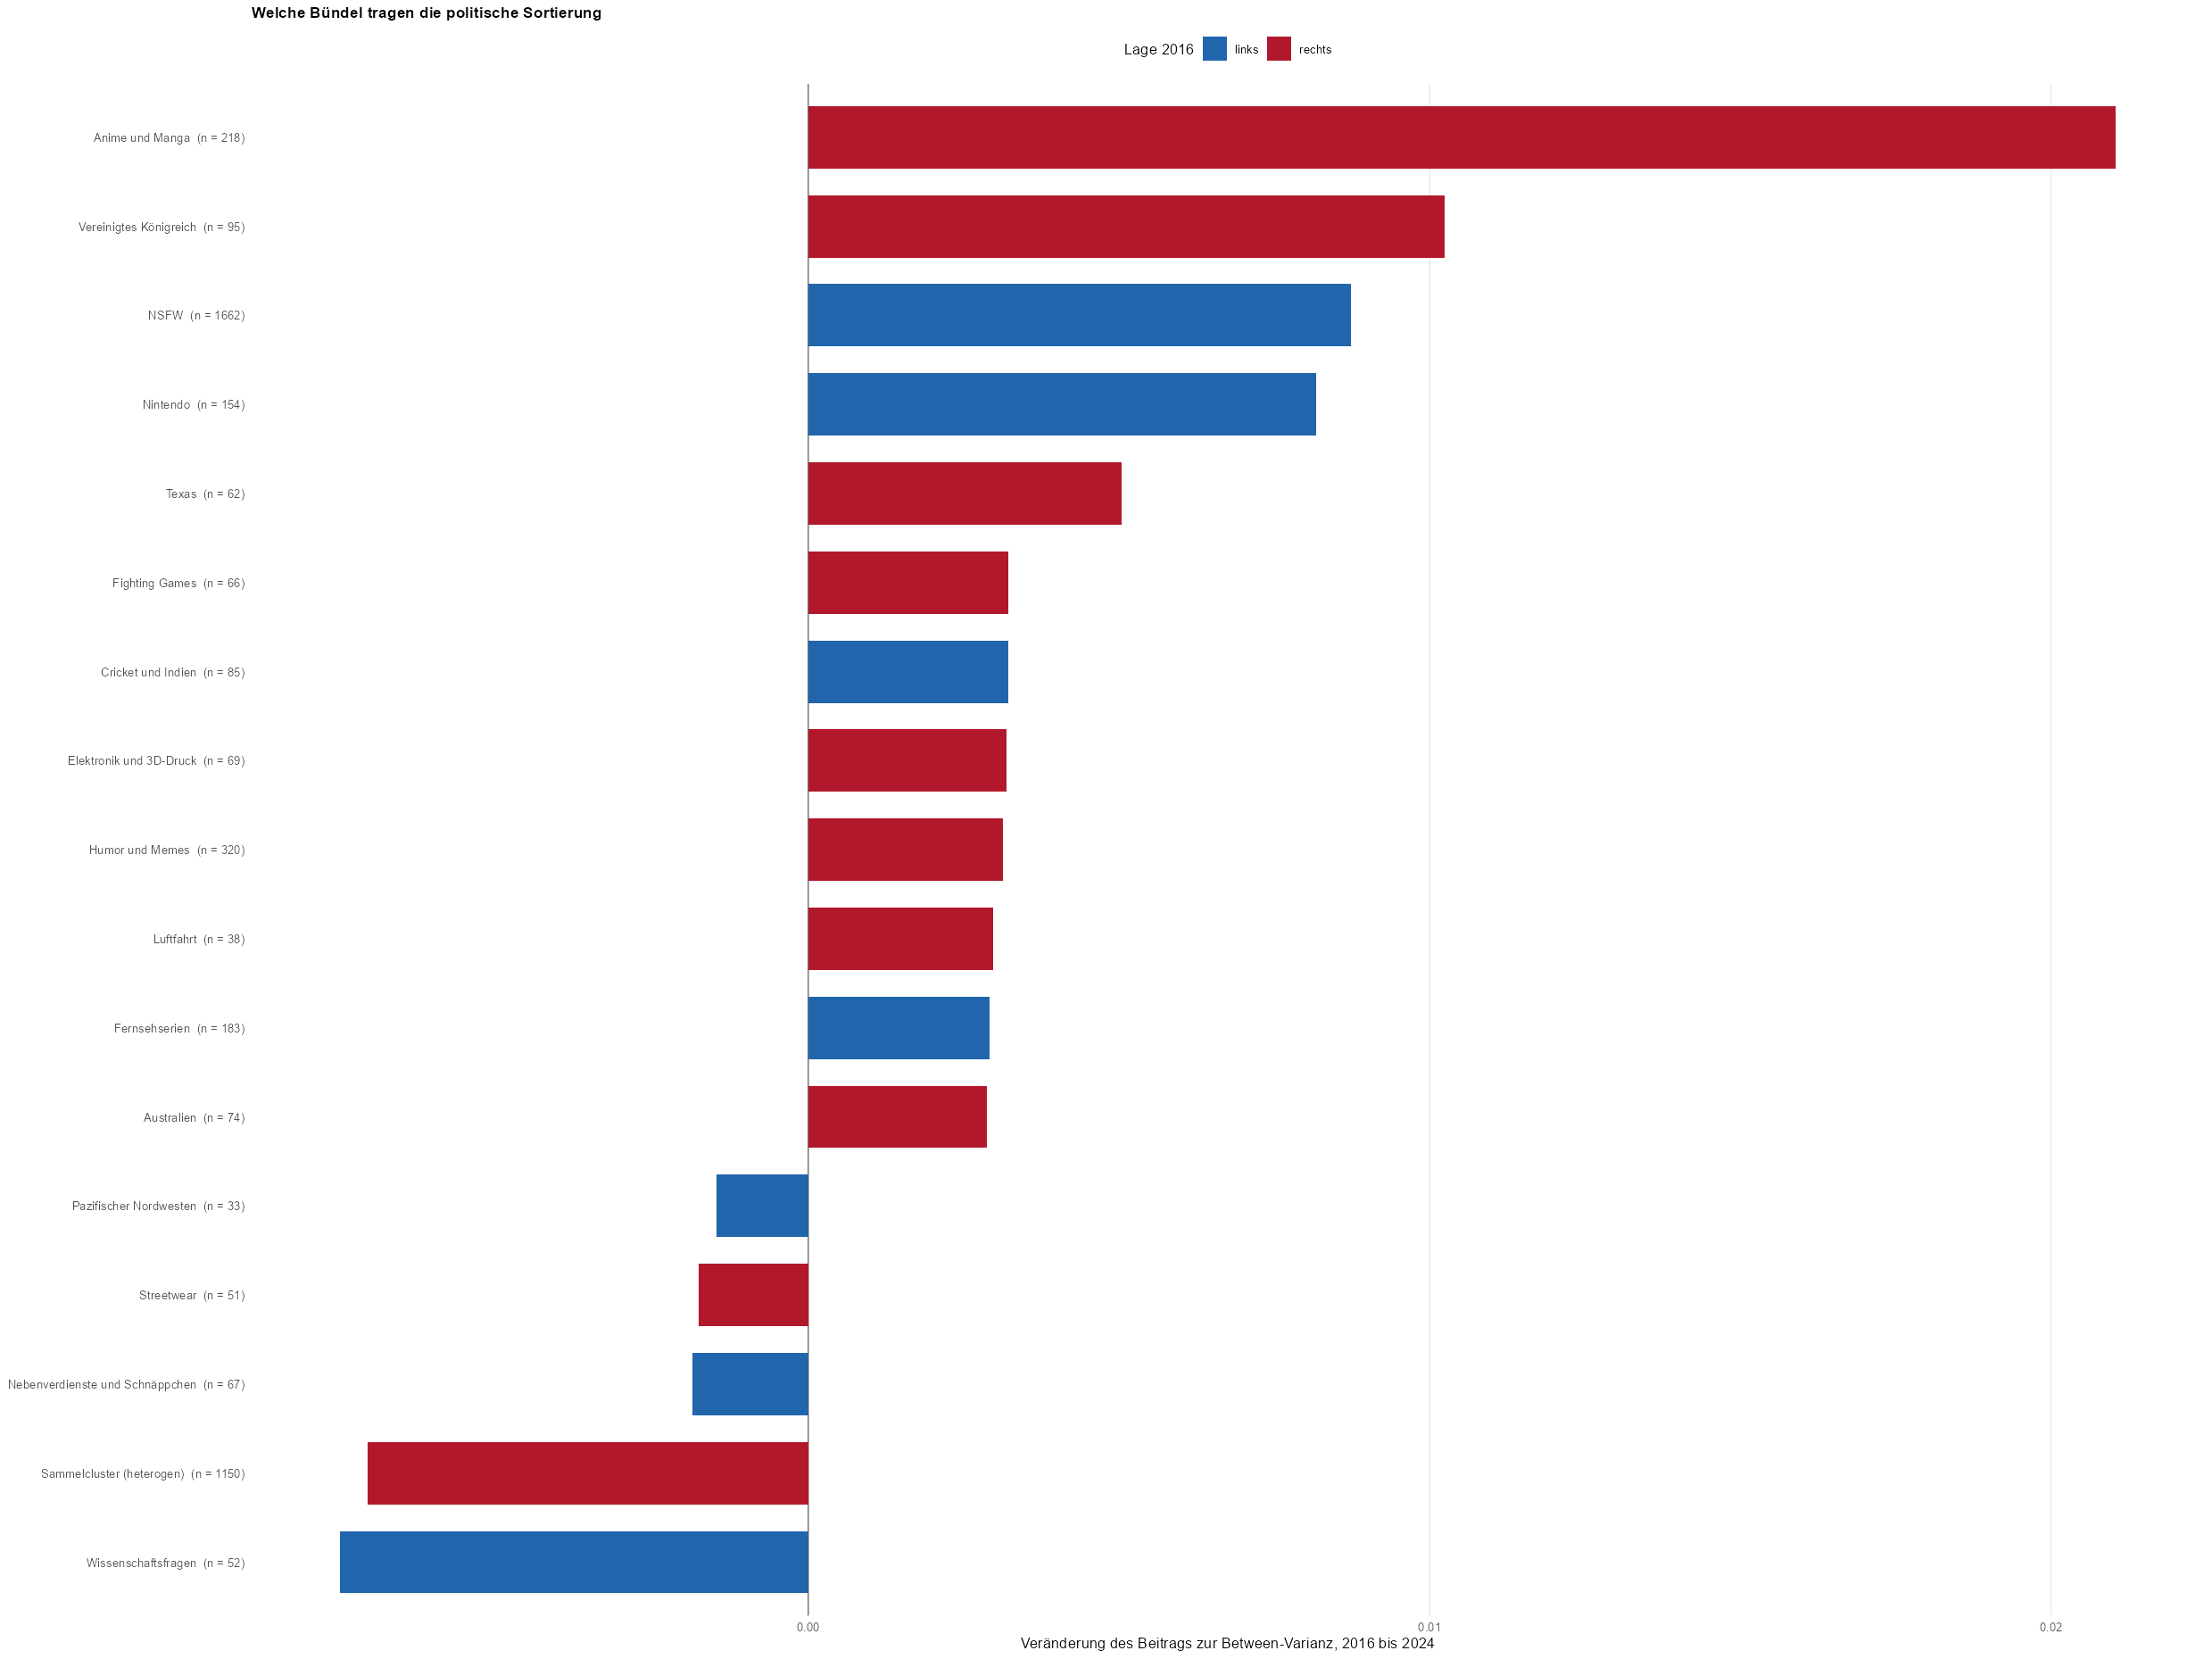

In [12]:
zer <- lies("ff3_beitrag_zerlegung.csv")
lin <- lies("ff3_linien_jaccard_pct.csv")

pal_seite <- c("links" = POL_LINKS, "rechts" = POL_RECHTS)

basis <- zer |>
  left_join(namen, by = "cluster") |>
  mutate(thema = coalesce(thema, paste0("Cluster ", cluster)),
         seite = if_else(d_2016 > 0, "rechts", "links"))

abb1_dat <- bind_rows(basis |> slice_max(d_beitrag, n = 12),
                      basis |> slice_min(d_beitrag, n = 5)) |>
  distinct(cluster, .keep_all = TRUE) |>
  mutate(thema = fct_reorder(paste0(thema, "  (n = ", n_subs, ")"), d_beitrag))

p1 <- ggplot(abb1_dat, aes(x = d_beitrag, y = thema, fill = seite)) +
  geom_vline(xintercept = 0, colour = "grey45", linewidth = 0.4) +
  geom_col(width = 0.7) +
  scale_fill_manual(values = pal_seite, name = "Lage 2016") +
  labs(x = "Veränderung des Beitrags zur Between-Varianz, 2016 bis 2024", y = NULL,
       title = "Welche Bündel tragen die politische Sortierung") +
  theme_minimal(base_size = 10) +
  theme(panel.grid.major.y = element_blank(), panel.grid.minor = element_blank(),
        panel.grid.major.x = element_line(colour = "grey92"),
        legend.position = "top", plot.title = element_text(face = "bold", size = 10.5))

ggsave(file.path(ABB_DIR, "ff3_abb1_beitrag.pdf"), p1,
       width = 16, height = 10.8, units = "cm", device = grDevices::cairo_pdf)
cat("  -> ff3_abb1_beitrag (pdf)\n")
p1

Mitgliedschafts-Gegenprobe: 1 von 53 Ketten verworfen (anteil_alt < 0.10).
  -> ff3_abb2_wanderung (pdf)


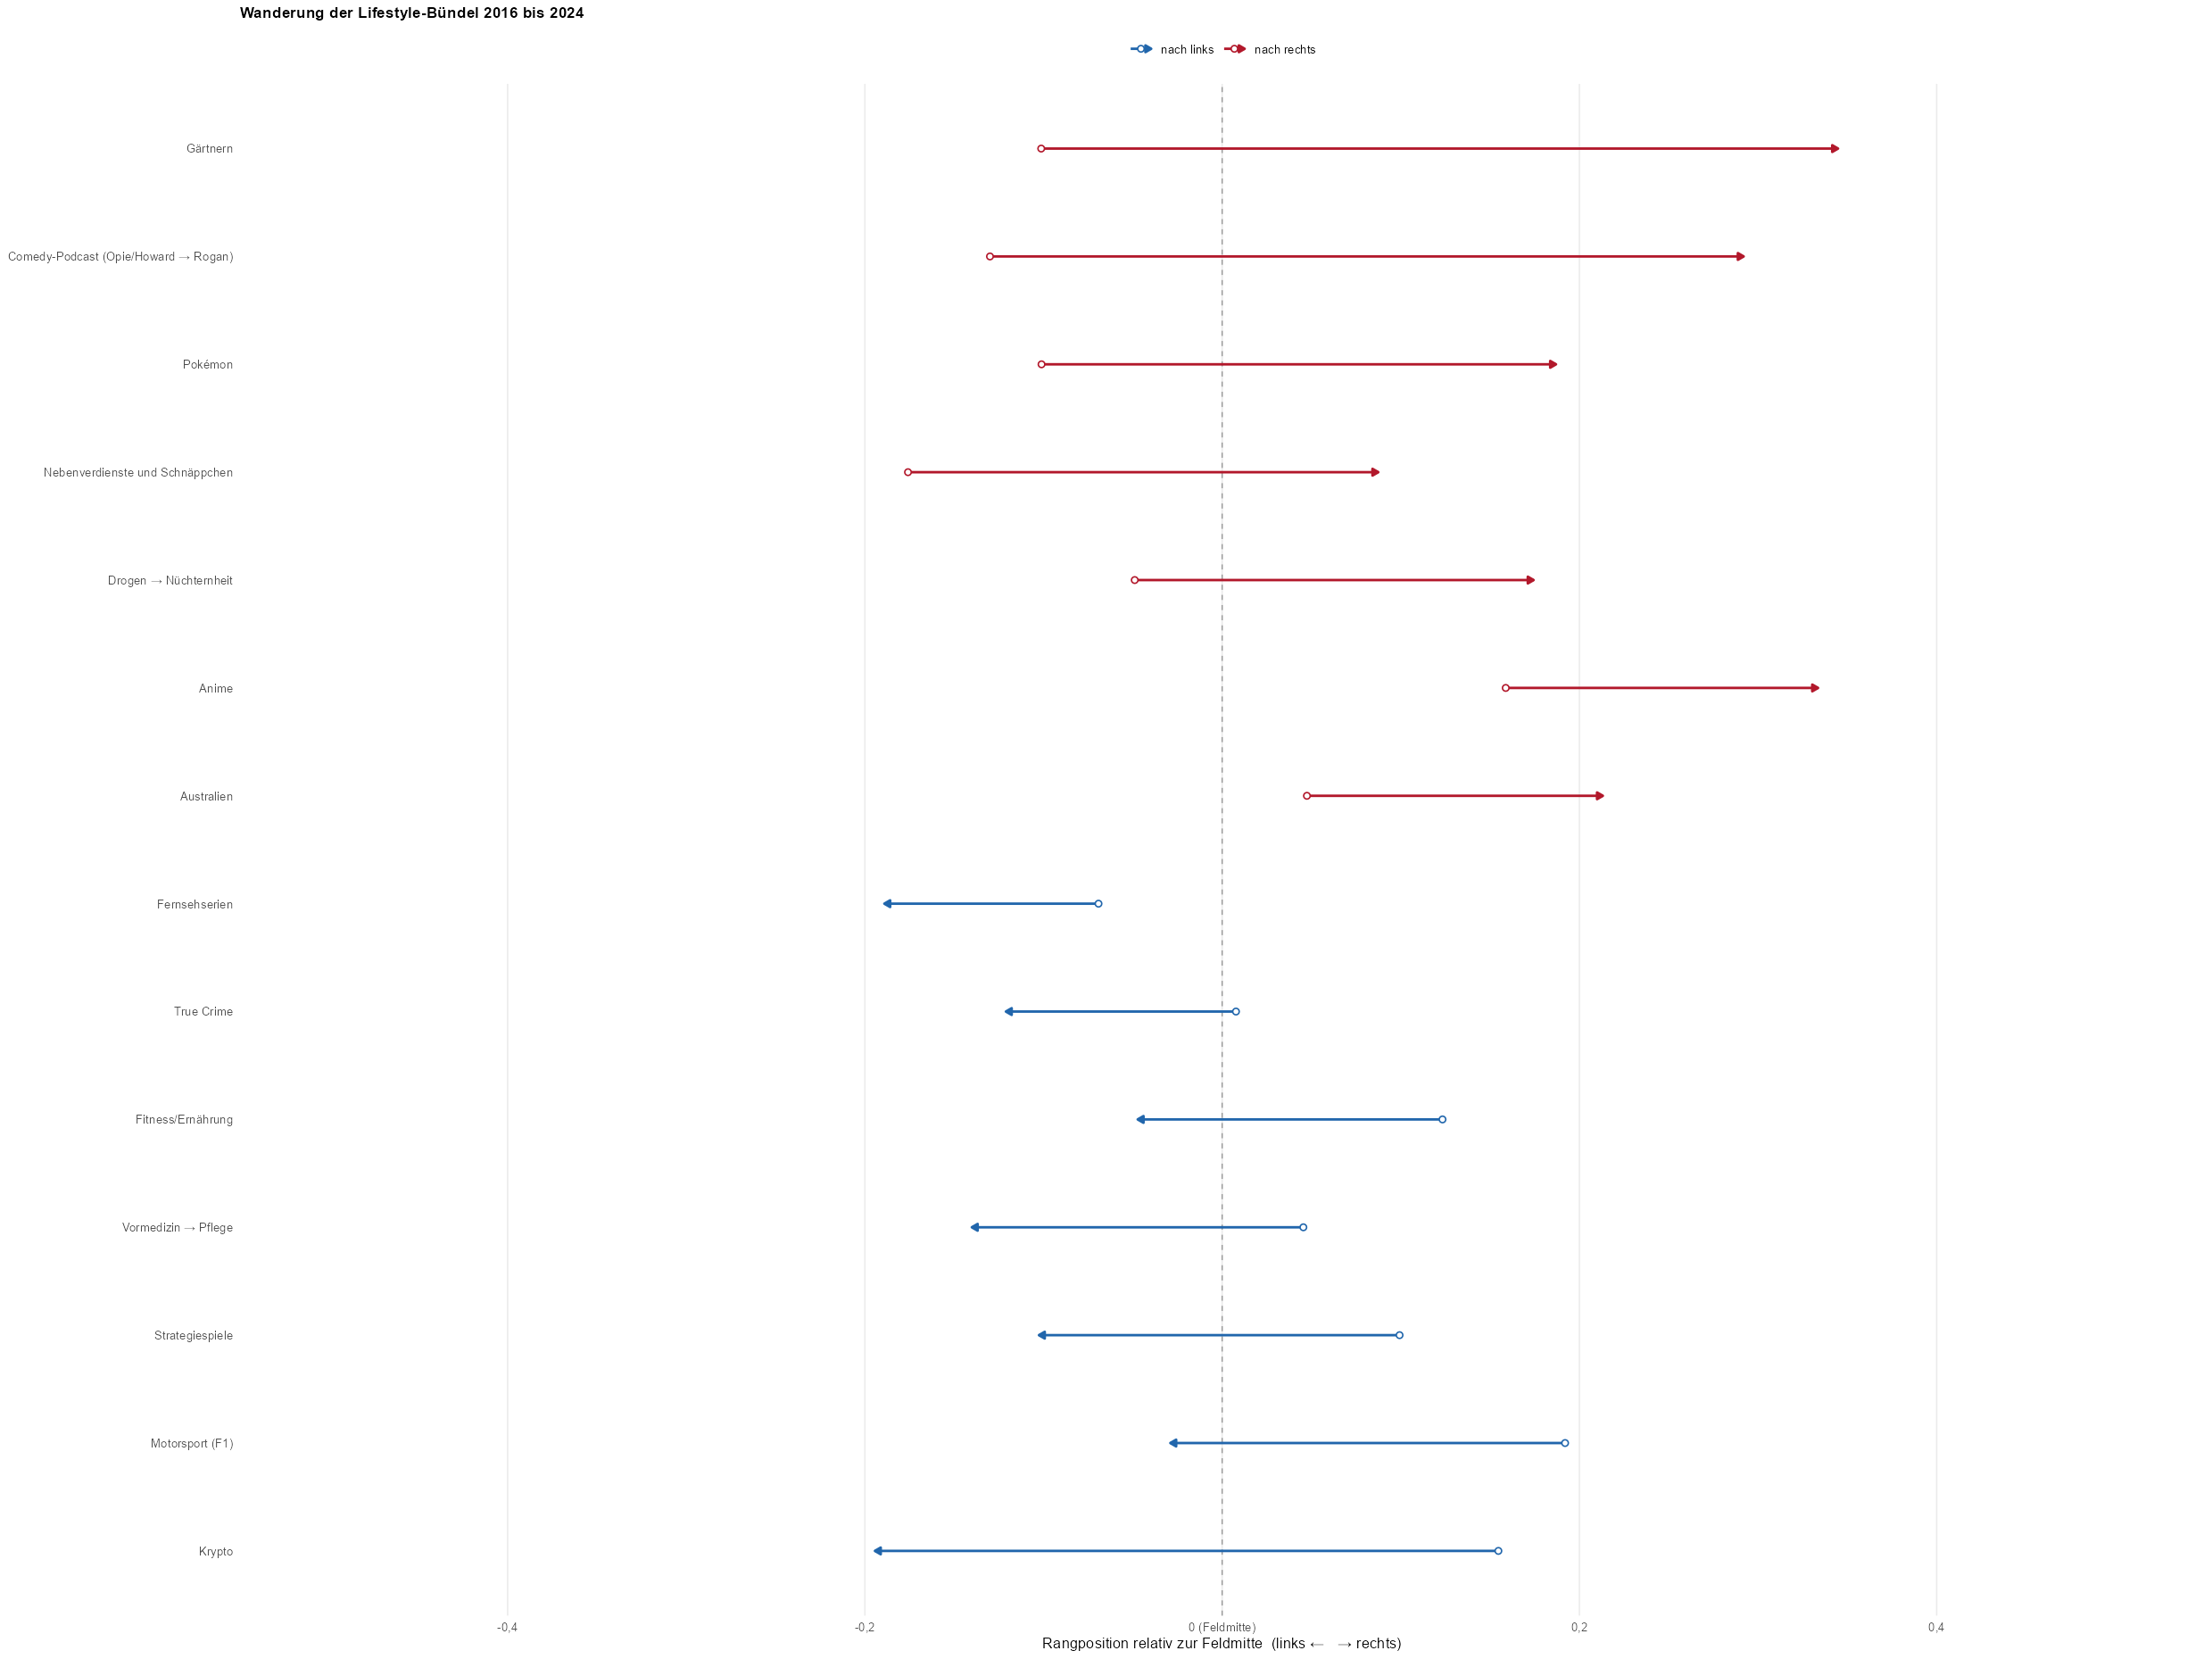

In [13]:
MIN_UEBERLAPP <- 0.10

rob <- lin |> filter(min_jacc >= 0.30, merge_n == 1)
vor <- nrow(rob)
rob <- rob |> filter(anteil_alt >= MIN_UEBERLAPP)
cat(sprintf("Mitgliedschafts-Gegenprobe: %d von %d Ketten verworfen (anteil_alt < %.2f).\n",
            vor - nrow(rob), vor, MIN_UEBERLAPP))

top <- bind_rows(rob |> slice_max(d_pct, n = 7), rob |> slice_min(d_pct, n = 7)) |>
  distinct(linie, .keep_all = TRUE)

# Eigene Beschriftung: hier tragen die Bündel längere Namen als in den
# Tabellen, weil der Wechsel selbst die Bildaussage ist.
label_map <- tibble::tribble(
  ~linie, ~thema,
  30, "Comedy-Podcast (Opie/Howard → Rogan)",
  54, "Gärtnern",
  83, "Pokémon",
  24, "Nebenverdienste und Schnäppchen",
  23, "Drogen → Nüchternheit",
  26, "Anime",
   4, "Australien",
  16, "Minecraft",
  36, "Fernsehserien",
   3, "NSFW",
   2, "Krypto",
  11, "Motorsport (F1)",
  84, "Strategiespiele",
  81, "Vormedizin → Pflege",
  57, "Fitness/Ernährung",
  64, "True Crime")

dat_plot <- top |>
  left_join(label_map, by = "linie") |>
  mutate(thema    = coalesce(thema, paste0("Linie ", linie)),
         richtung = if_else(d_pct > 0, "nach rechts", "nach links"),
         x_2016   = mean_pct_2016 - 0.5,     # 0 = Median des Feldes
         x_2024   = mean_pct_2024 - 0.5,
         thema    = fct_reorder(thema, d_pct))

p2 <- ggplot(dat_plot, aes(y = thema, colour = richtung)) +
  geom_vline(xintercept = 0, linetype = "dashed", colour = "grey60", linewidth = 0.4) +
  geom_segment(aes(x = x_2016, xend = x_2024, yend = thema),
               arrow = arrow(length = unit(0.16, "cm"), type = "closed"), linewidth = 0.8) +
  geom_point(aes(x = x_2016), size = 1.6, shape = 21, fill = "white", stroke = 0.7) +
  scale_colour_manual(values = c("nach links" = POL_LINKS, "nach rechts" = POL_RECHTS),
                      name = NULL) +
  scale_x_continuous(limits = c(-0.5, 0.5), breaks = c(-0.4, -0.2, 0, 0.2, 0.4),
                     labels = c("-0,4", "-0,2", "0 (Feldmitte)", "0,2", "0,4")) +
  labs(x = "Rangposition relativ zur Feldmitte  (links ←   → rechts)", y = NULL,
       title = "Wanderung der Lifestyle-Bündel 2016 bis 2024") +
  theme_minimal(base_size = 10) +
  theme(panel.grid.major.y = element_blank(), panel.grid.minor = element_blank(),
        panel.grid.major.x = element_line(colour = "grey92"),
        legend.position = "top", plot.title = element_text(face = "bold", size = 10.5))

ggsave(file.path(ABB_DIR, "ff3_abb2_wanderung.pdf"), p2,
       width = 16, height = 10.4, units = "cm", device = grDevices::cairo_pdf)
cat("  -> ff3_abb2_wanderung (pdf)\n")
p2

  -> ff3_abb3_konzentration (pdf)


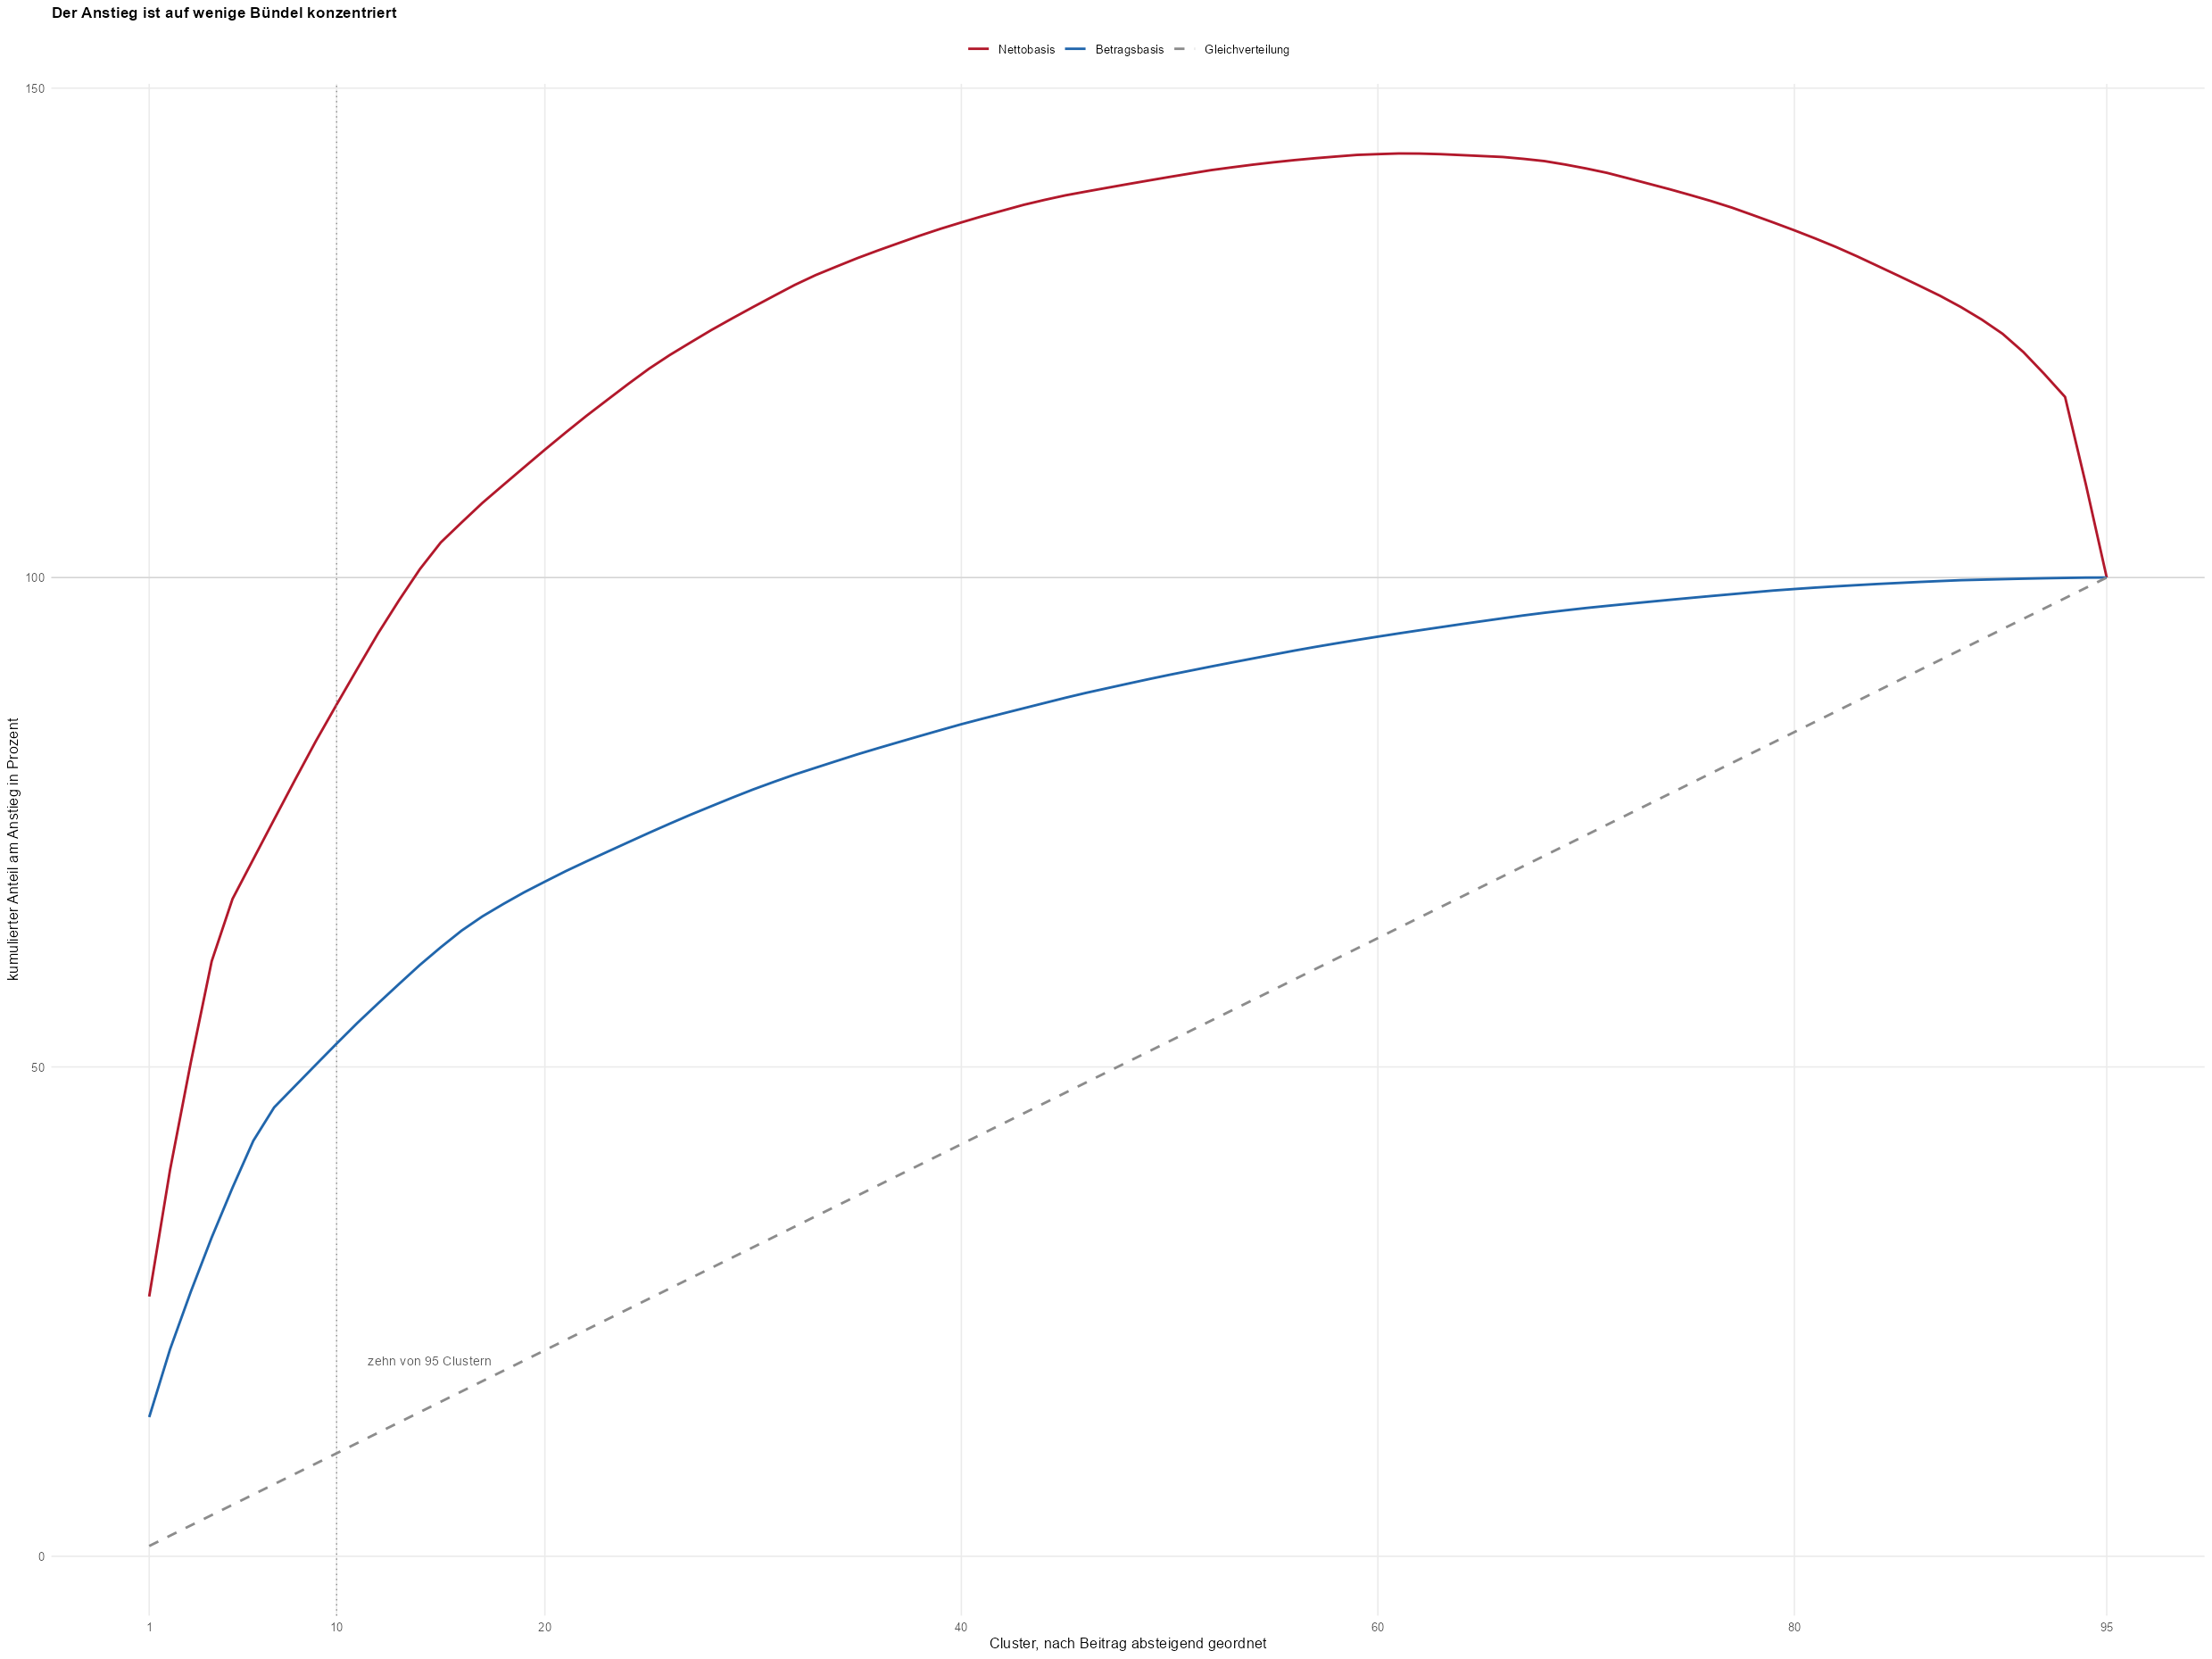

In [14]:
kum <- tibble(
  rang   = seq_len(nrow(zer)),
  netto  = 100 * cumsum(sort(zer$d_beitrag,      decreasing = TRUE)) / sum(zer$d_beitrag),
  betrag = 100 * cumsum(sort(abs(zer$d_beitrag), decreasing = TRUE)) / sum(abs(zer$d_beitrag)),
  gleich = 100 * seq_len(nrow(zer)) / nrow(zer)) |>
  pivot_longer(c(netto, betrag, gleich), names_to = "basis", values_to = "anteil") |>
  mutate(basis = factor(basis, levels = c("netto", "betrag", "gleich"),
                        labels = c("Nettobasis", "Betragsbasis", "Gleichverteilung")))

p3 <- ggplot(kum, aes(rang, anteil, colour = basis, linetype = basis)) +
  geom_hline(yintercept = 100, colour = "grey80", linewidth = 0.3) +
  geom_line(linewidth = 0.8) +
  geom_vline(xintercept = 10, linetype = "dotted", colour = "grey55", linewidth = 0.4) +
  annotate("text", x = 11.5, y = 20, hjust = 0, size = 3.1, colour = "grey35",
           label = paste("zehn von", nrow(zer), "Clustern")) +
  scale_colour_manual(values = c("Nettobasis" = POL_RECHTS, "Betragsbasis" = POL_LINKS,
                                 "Gleichverteilung" = "grey55"), name = NULL) +
  scale_linetype_manual(values = c("solid", "solid", "dashed"), name = NULL) +
  scale_x_continuous(breaks = c(1, 10, 20, 40, 60, 80, nrow(zer))) +
  labs(x = "Cluster, nach Beitrag absteigend geordnet",
       y = "kumulierter Anteil am Anstieg in Prozent",
       title = "Der Anstieg ist auf wenige Bündel konzentriert") +
  theme_minimal(base_size = 10) +
  theme(panel.grid.minor = element_blank(), legend.position = "top",
        plot.title = element_text(face = "bold", size = 10.5))

ggsave(file.path(ABB_DIR, "ff3_abb3_konzentration.pdf"), p3,
       width = 16, height = 10.8, units = "cm", device = grDevices::cairo_pdf)
cat("  -> ff3_abb3_konzentration (pdf)\n")
p3

Hinweis: Cluster 88, 17 stehen in der Beschriftungsliste, sind aber nicht in der Teilmenge.
  -> ff3_abb4_mechanismus (pdf)
52 Ketten gezeigt, davon 10 benannt. Korrelation fix gegen Linie: 0.804


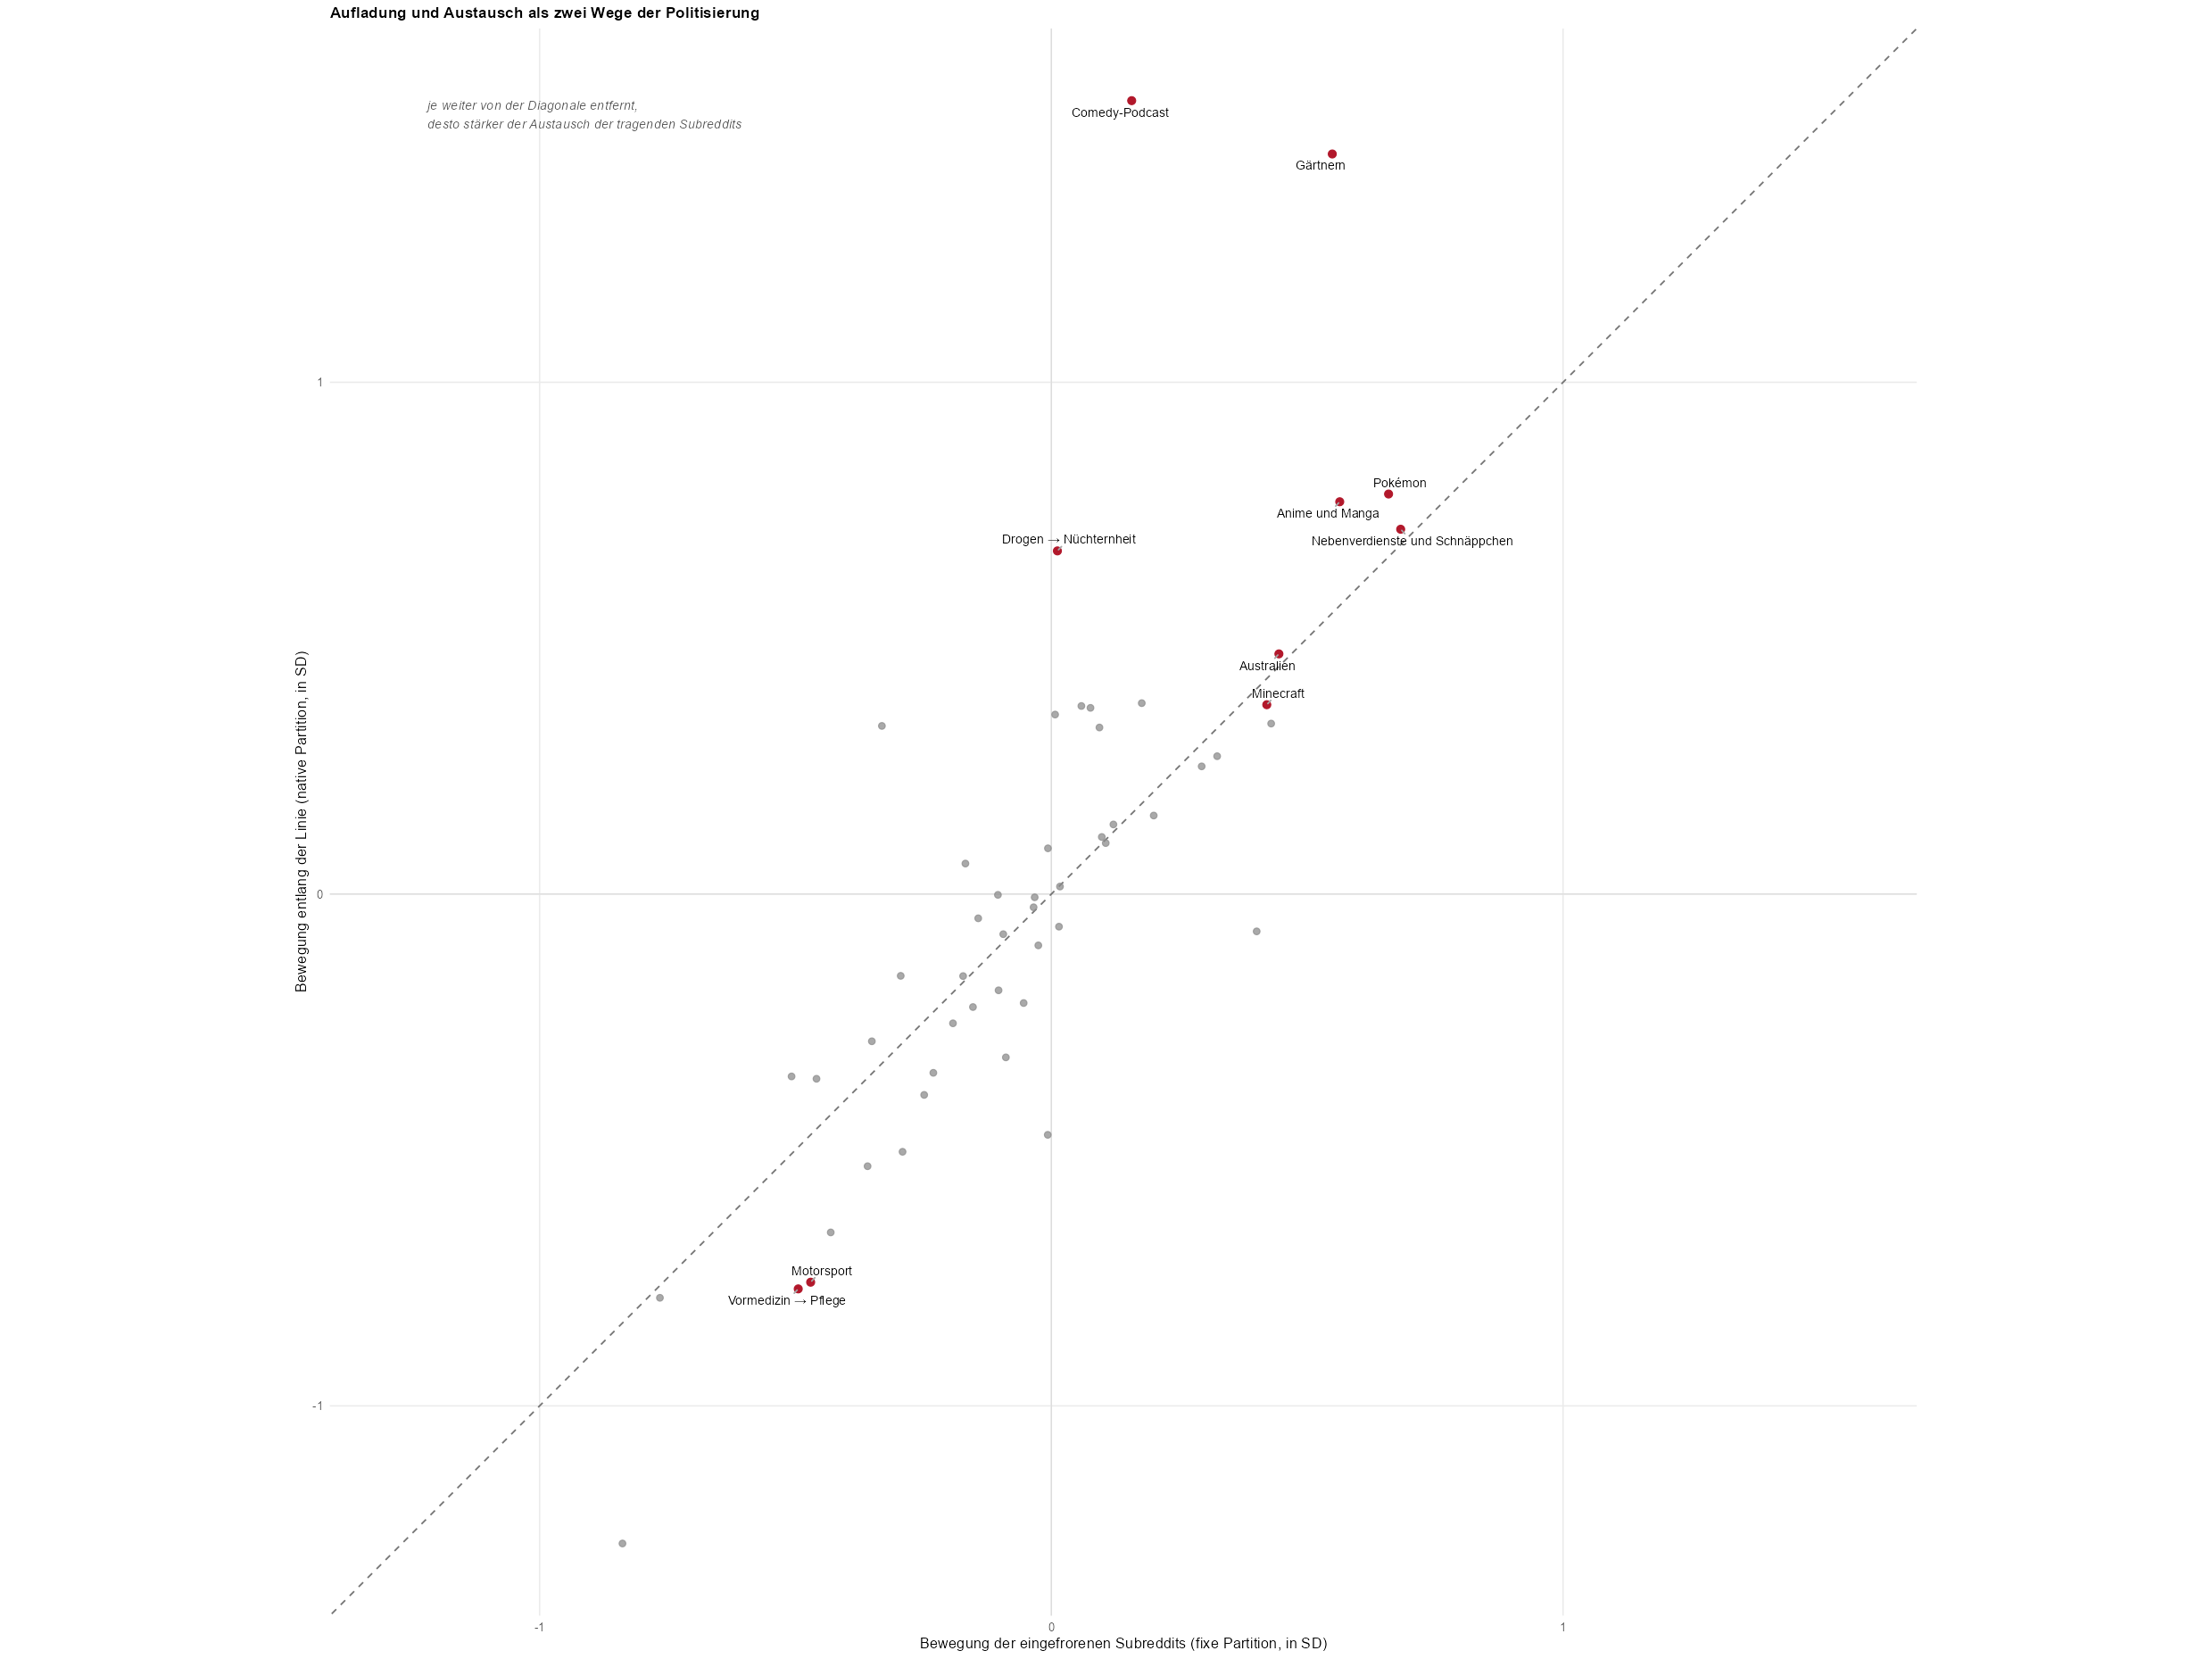

In [15]:
mech <- zer |>
  select(cluster, mittel_2016, mittel_2024) |>
  inner_join(lin |> select(cluster = cl_2016, d_z_linie = d_z, min_jacc, merge_n, anteil_alt),
             by = "cluster") |>
  filter(min_jacc >= 0.30, merge_n == 1, anteil_alt >= 0.10) |>
  mutate(d_z_fix = mittel_2024 - mittel_2016) |>
  left_join(namen, by = "cluster")

# Zwei der genannten Cluster fallen durch die Filter und werden von ggplot
# stillschweigend nicht beschriftet. Bewusst in der Liste belassen, damit die
# Prüfung darunter anschlägt, falls sich die Schwellen ändern.
zeig  <- c(30, 54, 23, 88, 26, 83, 24, 4, 16, 81, 11, 17)
fehlt <- setdiff(zeig, mech$cluster)
if (length(fehlt))
  cat("Hinweis: Cluster", paste(fehlt, collapse = ", "),
      "stehen in der Beschriftungsliste, sind aber nicht in der Teilmenge.\n")

lim <- range(c(mech$d_z_fix, mech$d_z_linie))

p4 <- ggplot(mech, aes(d_z_fix, d_z_linie)) +
  geom_hline(yintercept = 0, colour = "grey85", linewidth = 0.3) +
  geom_vline(xintercept = 0, colour = "grey85", linewidth = 0.3) +
  geom_abline(slope = 1, intercept = 0, linetype = "dashed", colour = "grey45", linewidth = 0.5) +
  geom_point(colour = "grey55", size = 1.8, alpha = 0.75) +
  geom_point(data = mech |> filter(cluster %in% zeig), colour = POL_RECHTS, size = 2.2) +
  ggrepel::geom_text_repel(data = mech |> filter(cluster %in% zeig), aes(label = thema),
                           size = 3, seed = 42, min.segment.length = 0.2,
                           segment.color = "grey65", max.overlaps = 20) +
  annotate("text", x = lim[1] + 0.05, y = lim[2], hjust = 0, vjust = 1, size = 3.1,
           colour = "grey35", fontface = "italic",
           label = "je weiter von der Diagonale entfernt,\ndesto stärker der Austausch der tragenden Subreddits") +
  coord_equal(xlim = lim, ylim = lim) +
  labs(x = "Bewegung der eingefrorenen Subreddits (fixe Partition, in SD)",
       y = "Bewegung entlang der Linie (native Partition, in SD)",
       title = "Aufladung und Austausch als zwei Wege der Politisierung") +
  theme_minimal(base_size = 10) +
  theme(panel.grid.minor = element_blank(),
        plot.title = element_text(face = "bold", size = 10.5))

ggsave(file.path(ABB_DIR, "ff3_abb4_mechanismus.pdf"), p4,
       width = 16, height = 14.6, units = "cm", device = grDevices::cairo_pdf)
cat("  -> ff3_abb4_mechanismus (pdf)\n")
cat(sprintf("%d Ketten gezeigt, davon %d benannt. Korrelation fix gegen Linie: %.3f\n",
            nrow(mech), sum(mech$cluster %in% zeig), cor(mech$d_z_fix, mech$d_z_linie)))
p4

In [16]:
sessionInfo()

R version 4.5.1 (2025-06-13 ucrt)
Platform: x86_64-w64-mingw32/x64
Running under: Windows 11 x64 (build 26200)

Matrix products: default
  LAPACK version 3.12.1

locale:
[1] LC_COLLATE=German_Germany.utf8  LC_CTYPE=German_Germany.utf8   
[3] LC_MONETARY=German_Germany.utf8 LC_NUMERIC=C                   
[5] LC_TIME=German_Germany.utf8    

time zone: Europe/Berlin
tzcode source: internal

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
 [1] lubridate_1.9.4   forcats_1.0.0     stringr_1.5.1     dplyr_1.1.4      
 [5] purrr_1.1.0       readr_2.1.5       tidyr_1.3.1       tibble_3.3.0     
 [9] ggplot2_3.5.2     tidyverse_2.0.0   dbscan_1.2.2      ineq_0.2-13      
[13] igraph_2.3.2      data.table_1.17.8

loaded via a namespace (and not attached):
 [1] bit_4.6.0          gtable_0.3.6       crayon_1.5.3       compiler_4.5.1    
 [5] tidyselect_1.2.1   Rcpp_1.1.0         parallel_4.5.1     textshaping_1.0.1 
 [9] 